# Academic impact of UK Biobank research

This notebook builds the comparative field analysis once, retains the distinct author and
publication-level diagnostics, and assembles manuscript Figure 5 and three supplementary
figures. Repeated standalone versions of the impact map, top-decile trends, quality
footprint and growth page have been removed.

All figures use the shared Helvetica stylesheet and project palette. Each image is
followed by its relative PDF/PNG paths and a suggested caption; captions are not exported
as separate files. The final manifest records only artifacts generated by this run.

Comparative field and author analyses use **2015-2025**. Showcase+ snapshot diagnostics
retain their distinct **2013-2025** cohort. These denominators are not interchangeable.


# Part I: Fields of Research (ANZSRC FoR 2020)

Where 20 years of UK Biobank publications sit inside the world literature, read through
the **ANZSRC 2020 Fields of Research** classification: how much UK Biobank publishes,
which fields it concentrates in, and how well that work is cited against everyone else
publishing in the same field in the same year.

**Two arms, one denominator.** Every number here compares two count tables built from one
file list: the **UK Biobank arm** (papers that use UK Biobank) and the **background arm**
(everything else Dimensions indexes). The two summed are the **whole database**, which is
the denominator for every share, index and ratio below. Nothing is compared against a
hand-picked control group.

**One publication window, everywhere: 2013–2025.** Both UK Biobank and background
publications use the inclusive 1 January 2013–31 December 2025 window. Citation totals
retain their snapshot date. Missing field-year citation references remain unavailable
and are reported separately; they do not move the publication window. §3.1 audits exclusions.

**The size fact that governs every reading.** UK Biobank is a small share of the tagged
literature; §3 prints the share for the current window. So a *share* of a field is small everywhere by
construction and mostly reproduces "which fields are big", and UK Biobank is far too small
to bend a whole-database curve — a rise during the study is a database-wide trend, not an effect.
The measures that survive this are the **activity index** (§4.5), the **relative citation
impact** (§5) and the **quality bands** (§6).

**Sections**

| § | question | output |
|---|---|---|
| 1 | Setup | environment, repo paths, shared `STYLE`, shared analysis module |
| 2 | Analysis parameters | every switch this run depends on, in one cell |
| 3 | Data layer | load both arms, run the guards, derive the analysis tables |
| 3.1 | **What the window excludes** | the corpus-to-analysis-set audit, for the methods section |
| 4 | **Volume** — how much, and where | Charts 1–4 + the marginal-growth table |
| 5 | **Citation impact** — how well it lands | Charts 5–7 |
| 6 | **Quality bands** — the cut-offs behind the percentiles | §6.1 + Charts 9, 9a, 10 |
| 7 | **Growth** — where UK Biobank is moving next | Chart 11 |

Chart numbers are stable: chart *n* saves as `0n_…` / `n_…` in `STYLE["savedir"]`, and the
same numbers are used in the sibling notebook.

> **Sibling notebook.** [`03_academic_impact_02_rcdc_analysis.ipynb`](../../doc/archive/03_academic_impact_02_rcdc_analysis.ipynb)
> runs this same analysis over the NIH **RCDC** disease/condition vocabulary. Everything the
> two must agree on — loading, guards, the activity index, the citation windows, the impact
> table — lives in `src/utils/data_analysis_03_academic_impact_analysis.py`; only the charts
> live in the notebooks, so a chart cell can be moved between them unchanged.


## 1. Setup

Imports, repo-anchored paths, and the shared plotting style.

* **Paths** — `shared_paths.bootstrap()` anchors every input/output on the repo root, so the
  notebook runs identically from the repo root, `src/`, or `src/data_analysis/`.
* **Style** — palette, font sizes and figure directory come from
  `universal_settings.yml` (`style.notebooks.03_academic_impact`), merged over the shared
  `base` by `load_style`, so every figure in this project draws from one file. `savefig`
  and `extended_palette` read the same registered `STYLE`.
* **Analysis module** — `data_analysis_03_academic_impact_analysis` (imported as `AI`) is
  the data layer shared with the RCDC notebook; see §3.


In [1]:
import json
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "utils").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import shared_paths as P
from utils.shared_analysis_window import ANALYSIS_START_YEAR, ANALYSIS_END_YEAR, filter_analysis_window
P.bootstrap()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from utils.shared_style import load_style
from utils import data_analysis_03_academic_impact_analysis as AI
from utils import data_analysis_03_academic_impact_panels as NP
from utils import data_analysis_03_academic_impact_figures as Q

STYLE = load_style("03_academic_impact")
ARTIFACTS = P.ArtifactRegistry(P.OUTPUT_TABLES / "03_academic_impact")
print("Figures:", P.raw_path(STYLE["savedir"]))


Figures: output/figures/data_analysis/03_academic_impact


## 2. Analysis parameters

Every switch this run depends on, in one cell: which level of the vocabulary to compare on,
how a multi-labelled paper is counted, which citation measures lead, the guards, the year
window, and which pathway produced the counts. Nothing downstream hard-codes a choice made
here, and the cell prints the resulting configuration so any figure can be traced back to it.

**The analysis window — 2013–2025, inclusive.** `ANALYSIS_MIN`/`ANALYSIS_MAX` and
`YEAR_MIN`/`YEAR_MAX` use the shared publication window for both arms, including volume,
activity and author impact. Publication dates are checked when available. Citation
counts retain their original snapshot date. Missing early citation references are
reported as unmeasured; the publication cohort still starts in 2013. Pre-2013 comparisons
are unavailable because those publications lie outside the study window.

**The vocabulary.** ANZSRC 2020 Fields of Research is a two-level hierarchy: `FOR_LEVEL="L4"`
compares fine fields (*4202 Epidemiology*), `"L2"` broad divisions (*42 Health Sciences*).
"Field" below always means a category at the level set here.

**Where the counts come from** (`SOURCE`):

* `"vm"` — counted row by row off the Dimensions corpus copy on BMRC by
  `src/utils/data_analysis_03_academic_impact_field_counts.py --category for`. A **fixed
  snapshot**, and the only pathway that can carry fractional counts and citation weights.
* `"api"` — **this run.** The whole-database counts faceted straight out of the Dimensions
  API by `src/utils/data_analysis_03_academic_impact_dimensions_api.py`, with the UK Biobank
  arm fetched per paper from the same live index in the same pass. Aggregates only on the
  background side, so there is no fractional column there and no per-paper FCR — but both
  arms are one index read on one day, which is what makes the subtraction
  `background = whole − ukbb` exact. The VM contributes only the id list that says which
  papers are UK Biobank's.

Both arms always come off one file list, and everything downstream adapts rather than
breaks: measures only one arm carries are dropped (and said so), the activity index falls
back to whole counting when there is no fractional column, and the citation sections skip
themselves.

**Sibling notebook.** A guard fixed here is fixed in
[`03_academic_impact_02_rcdc_analysis.ipynb`](../../doc/archive/03_academic_impact_02_rcdc_analysis.ipynb)
too — the shared logic lives in `src/utils/data_analysis_03_academic_impact_analysis.py`.


In [2]:
COL_TYPE = "for"

# Which level of the hierarchy to compare on:
#   "L4" = fine field       (e.g. 4202 Epidemiology)
#   "L2" = broad division   (e.g. 42 Health Sciences)
FOR_LEVEL = "L4"

# FOR has no sub-vocabulary to slice; the RCDC notebook uses this to separate diseases
# from cross-cutting tags. Kept here so both notebooks share one build cell verbatim.
RCDC_VIEW = "all"

# THE ANALYSIS WINDOW ---------------------------------------------------------
# Every primary analysis includes publications from 2015 through 2025 (D19).
# Early papers remain in volume and eligible citation metrics. A field-year without
# a measured citation reference remains unavailable; it is never assigned zero impact.
#
# 2015, NOT the project-wide ANALYSIS_START_YEAR of 2013. The shared constant is where
# the CORPUS is cut; this is where this analysis can MEASURE. Three independent limits
# put it two years higher: UK Biobank published 27 papers in 2014 against 63 in 2015,
# `percentiles --min-ukbb 10` measured no 2014 cell in any field so field_thresholds.csv
# has no 2014 row at all, and CITE_MIN_DOCS would drop 2014 regardless. D19 considered
# 2014 for a rounder window and rejected it.
ANALYSIS_MIN = 2015
ANALYSIS_MAX = ANALYSIS_END_YEAR

# Kept under its old name because the module's signature and the charts' "first year"
# reference line both use it; it now means the first year of the analysis window.
UKBB_YEAR = ANALYSIS_MIN

# How many of UK Biobank's OWN top fields to follow through the whole database.
TOP_N = 8

# Counting metric for the VOLUME charts:
#   "n_papers" = a paper counts once in EVERY field it carries (absolute)
#   "n_frac"   = its weight split evenly across its fields (per-level fractional)
# For FOR the two agree closely, unlike RCDC where a UK Biobank paper carries nearly twice
# the tags of an average one. UK Biobank carries 1.49 L4 codes per paper, measured
# directly off the records (§3.1 prints it). The database's own figure CANNOT be measured
# this way — a facet returns per-cell totals, never the union of papers behind them — so
# the closest available check is the L4/L2 count ratio over the window: 1.06 for the
# database against 0.99 for UK Biobank. Close enough that n_papers and n_frac agree. Shares of a single field are absolute; anything comparing ACROSS fields
# uses the fractional columns regardless of this line.
WEIGHT = "n_papers"

# CITATION METRICS ------------------------------------------------------------
# Which citation quantities exist depends on how the counts were built; this run (API)
# carries four, and the loader prints the list it actually found:
#   "n_cit"     raw times_cited        — citation mass. Accrues with age, and is NOT
#                                        normalised by year, so it is used for SHARES
#                                        and descriptive means only — never as an
#                                        rci_ ratio. See RCI_WEIGHTS in the module.
#   "n_mncs"    times_cited / the mean of its own (year, field) — 1.0 = the field's
#                                        average paper that year. The headline.
#   "n_top10f"  1.0 if the paper is in the most-cited tenth OF ITS OWN (year, field),
#                                        against a cut-off MEASURED by counting
#                                        (dimensions_api.py deciles).
#   "n_top50f"  1.0 if it is at or above that (year, field)'s MEDIAN.
# The VM pathway carries "n_fcr" (Dimensions' own field citation ratio) and "n_top10"
# (the decile of the whole corpus rather than of the field) in place of the last two.
#
# NOT CARRIED ANY MORE: "n_top10p", the proxy that called a paper top-decile when its
# mncs cleared a K calibrated per (year, type). The `deciles` mode measures the real
# per-field cut-off now, so the proxy adds nothing — and it was the weight with the
# shortest usable window, which held the whole impact window back a year. The column is
# no longer in the partials either: the current API run does not write it, and the
# analysis module does not list it. Both would have to be put back to see it again.
#
# CITE_HEADLINE   the intensity measure the impact map and the time panel lead with.
#                 A REQUEST, not a fact: if the run has no FCR (the API pathway does
#                 not) the loader substitutes n_mncs and says so.
# CITE_SHARE_METRIC  what Chart 7 tracks: UK Biobank's share of the world's ___ in a
#                 field. Set it to "n_papers" to see the volume baseline on the same
#                 axes, or "n_cit" for the share of the field's citations.
CITE_HEADLINE = "n_mncs"
CITE_SHARE_METRIC = "n_top10f"

# WHERE THE MEASURING FLOOR IS ------------------------------------------------
# The API job measures a (year, field) cut-off only where UK Biobank has at least this
# many papers in the cell — `percentiles --min-ukbb` in
# data_analysis_03_academic_impact_dimensions_api.py. It is written down here because the
# notebook's own per-year floor has to sit AT OR ABOVE it: a year-cell this notebook is
# willing to DRAW has to be one that was MEASURED, or the panel loses its left edge to
# cells that were never thresholded.
API_MIN_UKBB = 10

# A field-window with a handful of UK Biobank papers has a mean citation rate that is
# noise, so the impact measures drop anything thinner than these. The two floors below are
# not the same quantity and are not comparable to each other:
#
#   CITE_MIN_DOCS       pooled over the WHOLE impact window. The floor under a field's
#                       single RCI number in the IMPACT table (charts 5 and 6-left): how
#                       many UK Biobank papers in that field carried a citation value at
#                       all, summed across every year of the window.
#   CITE_MIN_DOCS_YEAR  within a SINGLE year. The floor under one cell of the RCI time
#                       series (chart 6, right), where a ratio of two means is at its
#                       noisiest, and the one that has to clear API_MIN_UKBB.
#
# 50 over the thirteen-year window is under four papers a year, so it is a far weaker
# per-year condition than CITE_MIN_DOCS_YEAR — a pooled figure survives thin years, an
# individual year does not.
CITE_MIN_DOCS = 50       # over the whole impact window
CITE_MIN_DOCS_YEAR = 20  # within a single year; >= API_MIN_UKBB by construction
assert CITE_MIN_DOCS_YEAR >= API_MIN_UKBB, (
    f"CITE_MIN_DOCS_YEAR ({CITE_MIN_DOCS_YEAR}) is below the API's measuring floor "
    f"({API_MIN_UKBB}): the notebook would draw year-cells whose cut-offs were never "
    f"measured. Raise it, or re-measure with "
    f"`percentiles --min-ukbb {CITE_MIN_DOCS_YEAR}`.")

# How the usable citation window is derived (see the module for the reasoning):
#   a year needs CITE_COV_MIN of papers measured IN BOTH ARMS to be usable at all, and
#   the weights that are NOT year-normalised then drop CITE_LAG further years, because
#   a 2024 paper has not been cited yet however completely it is indexed.
#
# CITE_LAG = 0, deliberately, and it is safe here because of WHICH weights this run
# carries. The lag protects a comparison that puts young papers against old ones. That
# cannot happen to any weight below:
#   n_mncs, n_top10f, n_top50f  are each scored against a reference measured INSIDE
#       their own (year, field) — the field's mean that year, the field's decile cut-off
#       that year, the field's median that year. A 2024 paper is judged against 2024's
#       bar. (The module lists all three in YEAR_NORMALISED, so the lag would not reach
#       them anyway; this line only ever bites n_cit.)
#   n_cit  is never divided into a ratio — see RCI_WEIGHTS and the note in §5. It is
#       used as a SHARE and as a descriptive mean, and in both the numerator and the
#       denominator are the same year's papers from the same index, so immaturity
#       cancels rather than biasing.
# Set it back to 1 if a weight that accrues with age is ever given a ratio.
CITE_COV_MIN = 0.5
CITE_LAG = 0

# WHAT THE ACTIVITY INDEX IS MEASURED AGAINST ---------------------------------
# The index is a ratio of shares, so it depends entirely on what "the database" means:
#   "global"         every paper Dimensions indexes, art history included
#   "universe"       restricted to UNIVERSE_DIVISIONS below
#   "within_parent"  each L4 field against its own L2 division, both arms
#
# Worth knowing before choosing: "universe" divides EVERY field's index by one and the
# same constant (historical calibration: 2.70 over 2015-2025 — UK Biobank has 93% of its mass in
# those divisions against the database's 34%), so it re-ranks nothing; it only moves where
# parity sits. "within_parent" is the one that removes "UK Biobank is a biomedical
# resource" from the comparison per field, and it does re-rank: Public Health reads 4.7x
# globally and 0.9x within Health Sciences — against all research it looks like a
# speciality, against health research UK Biobank is slightly under-represented in it.
# Epidemiology 61.4x -> 12.0x.
ACTIVITY_BASE = "within_parent"
UNIVERSE_DIVISIONS = ("31", "32", "42", "52")   # bio, biomedical, health, psychology

# How far back the BACKGROUND arm is carried. D19 sets this to 2004 so a field's
# twenty-year trend has something to be a trend against, and it is deliberately NOT part
# of the analysis window. It is left at the project floor here because `AI.load_arm` puts
# every partial through `filter_analysis_window` before applying year_min, and that
# filter floors at 2013 — so a 2004 written here would be discarded and read as a longer
# history than the charts actually have. Relax that filter for the background arm before
# restoring 2004.
YEAR_MIN = ANALYSIS_START_YEAR
YEAR_MAX = ANALYSIS_MAX

BEFORE_WIN = None                         # pre-study years are outside this analysis
AFTER_WIN  = (ANALYSIS_MIN, ANALYSIS_MAX)     # the analysis window itself

# LABEL QUALITY GUARD ---------------------------------------------------------
# A year where the background arm's category labels came back blank has no usable
# whole-database denominator, so any share computed from it is meaningless. Both
# guards are tripwires: with both arms counted from one snapshot they are currently
# inert, and that is exactly when they are worth keeping.
BLANK_MAX = 0.05
MASK_BAD_DENOM = True

# VOCABULARY SKEW GUARD -------------------------------------------------------
# A tag whose vocabulary changed between two snapshots has a real numerator and a
# near-empty denominator. Any field where UK Biobank exceeds this share of the world
# is that artefact, not a finding. None keeps them.
SKEW_MAX_SHARE = 5.0

# WHERE THE COUNTS COME FROM ---------------------------------------------------
# Two pathways produce the same tables, and both are kept because they answer
# different amounts of the question:
#
#   "vm"   counted row by row off the Dimensions corpus copy on BMRC by
#          data_analysis_03_academic_impact_field_counts.py. Slow to run, but it is a
#          FIXED SNAPSHOT and it can count anything a row contains — fractional counts,
#          citation weights, the top-decile indicator.
#   "api"  the whole-database counts faceted straight out of the Dimensions API by
#          data_analysis_03_academic_impact_dimensions_api.py — about twenty queries for
#          the whole year x field matrix. Aggregates only: no fractional column and no
#          citation weights, and it is the LIVE index rather than the snapshot the UK
#          Biobank arm came from.
#
# Everything downstream adapts rather than breaks: the loader drops any measure only one
# arm carries and says so, the activity index falls back to whole counting when there is
# no fractional column, and the citation sections skip themselves.
SOURCE = "api"

# WHERE THE PARTIALS LIVE ------------------------------------------------------
# One output directory holds every category's partials; they are named per-category,
# and the two pathways write the same filenames into different directories.
COUNTS_DIR = AI.resolve_counts_dir(P.FOR_COUNTS if SOURCE == "vm" else P.FOR_COUNTS_API)

print(f"source={SOURCE}   category={COL_TYPE}   level={FOR_LEVEL}   weight={WEIGHT}   top-N={TOP_N}")
print(f"citation: headline={CITE_HEADLINE}  share metric={CITE_SHARE_METRIC}  lag={CITE_LAG}")
print(f"ANALYSIS WINDOW {ANALYSIS_MIN}-{ANALYSIS_MAX} — every UK Biobank measure, volume "
      f"and citation alike")
print(f"background history {YEAR_MIN}-{YEAR_MAX}   before={BEFORE_WIN}  after={AFTER_WIN}")


source=api   category=for   level=L4   weight=n_papers   top-N=8
citation: headline=n_mncs  share metric=n_top10f  lag=0
ANALYSIS WINDOW 2015-2025 — every UK Biobank measure, volume and citation alike
background history 2013-2025   before=None  after=(2015, 2025)


## 3. Data layer — load both arms, run the guards, derive the analysis tables

One call does the whole data layer: resolve which partials belong to which arm, drop
blank-labelled years, build the whole-database denominator (= both arms summed), rank UK
Biobank's own top fields, compute the activity index, derive the usable citation window
from coverage, and build the per-field impact table.

**Read the printed output** — it says what was guarded against as it went, which is the
difference between "this field shrank" and "the classification got sparser that year". It
closes with UK Biobank's overall share of the database and its top `TOP_N` fields with
share and activity index side by side.

`globals().update()` is deliberate: it puts the frames into the notebook under their own
names (`whole_ts`, `TOP_CODES`, `IMPACT`, …), so a chart cell reads the same here as in the
RCDC notebook and can be moved between them unchanged. Everything it injects is listed in
`AI.build`'s docstring.


In [3]:
CTX = AI.build(
    COUNTS_DIR, COL_TYPE,
    level=FOR_LEVEL, rcdc_view=RCDC_VIEW,
    year_min=YEAR_MIN, year_max=YEAR_MAX, ukbb_year=UKBB_YEAR,
    top_n=TOP_N, weight=WEIGHT, palette=NP.field_palette,
    blank_max=BLANK_MAX, mask_bad_denom=MASK_BAD_DENOM,
    skew_max_share=SKEW_MAX_SHARE,
    cite_headline=CITE_HEADLINE, cite_min_docs=CITE_MIN_DOCS,
    cite_cov_min=CITE_COV_MIN, cite_lag=CITE_LAG,
    activity_base=ACTIVITY_BASE, universe_divisions=UNIVERSE_DIVISIONS,
)
globals().update(CTX)

# FRAC_COL is n_frac when both arms carry fractional counts and n_papers when they do
# not (the API pathway) — the loader has already said which, and why.
_ukbb_overall = (ukbb[ukbb.year.between(*AFTER_WIN)][FRAC_COL].sum()
                 / whole[whole.year.between(*AFTER_WIN)][FRAC_COL].sum() * 100)
print(f"\nUK Biobank is {_ukbb_overall:.3f}% of the whole database over {AFTER_WIN[0]}-"
      f"{AFTER_WIN[1]} ({FRAC_COL}), so read\nthe activity index, not the share, for "
      f"where it concentrates.\n")
print(f"UK Biobank top {TOP_N} {SYSTEM} {UNIT}s ({LEVEL}{VIEW_NOTE}, by {VALUE}, "
      f"{UKBB_YEAR}+):\n")
for code, lab in zip(TOP_CODES, TOP_LABELS):
    # Keep each displayed total aligned with the declared publication window.
    tot = int(ukbb[(ukbb.for_label == lab)
                   & ukbb.year.between(ANALYSIS_MIN, ANALYSIS_MAX)][VALUE].sum())
    ai = ACTIVITY.get(code, np.nan)
    print(f"  {AI.short(lab, 44):44s} UKBB {tot:>7,}   share@{YEAR_MAX} "
          f"{pct(share_at(lab), 2):>7s}   activity {ai:5.1f}x")
print(f"\n(activity index measured {ACTIVITY_LABEL} — ACTIVITY_BASE={ACTIVITY_BASE})")


loading for partials from data/analysis/academic_impact/for_counts_api
  ukbb       1 partial(s), 613 rows, 113 fields, blank labels 0.0%
  background 1 partial(s), 2,223 rows, 171 fields, blank labels 0.0%
  !! only one arm carries n_frac, n_cit_frac, n_cit_docs_frac, n_fcr, n_fcr_frac, n_fcr_docs, n_fcr_docs_frac, n_recent, n_recent_frac, n_recent_docs, n_recent_docs_frac, n_mncs_frac, n_mncs_docs_frac, n_top10f_frac, n_top10f_docs_frac, n_top50f_frac, n_top50f_docs_frac — dropped, because the whole-database
     total for a one-armed measure is just that arm again. Everything below uses
     n_papers where it would have used n_frac.
  measures: n_papers, n_cit, n_cit_docs, n_mncs, n_mncs_docs, n_top10f, n_top10f_docs, n_top50f, n_top50f_docs
  citation weights: n_cit, n_top10f, n_top50f, n_mncs
  no relative ratio for n_cit — not normalised by publication year, and the two arms'
     papers are not spread over the window alike. Shares and means only (see RCI_WEIGHTS).

activity inde

### 3.1 What the window excludes — the corpus-to-analysis-set audit *(for the methods section)*

Every number in this notebook describes the papers that survived §2's window and the
classification. This cell counts the ones that did not, so the methods section can state the
analysis set exactly rather than describing it as "UK Biobank publications".

It walks the funnel in the order the pipeline applies it:

| step | what is lost |
|---|---|
| ids submitted → records returned | ids the live index no longer resolves (retracted, merged, re-identified) |
| all years → `ANALYSIS_MIN`-`ANALYSIS_MAX` | papers below the window, and papers above it |
| tagged → L4-tagged | papers Dimensions gives no Fields of Research code, or only a 2-digit division |

**The top of the window.** The UK Biobank arm is fetched per paper, so it holds every year
the index does — including 2026. 2025 was added to the background arm by a top-up
(§2 lists the four commands) and is fully in the analysis. **2026 is excluded because it is
a part-year**: it is August 2026 as this runs, so the year holds roughly two thirds of a
year's papers with a fraction of a year's citations, and drawing it would show a collapse
where there is only a calendar. It comes in when the year closes.

The bottom of the window *is* a methodological choice, and §2 gives the three floors that
agree on it. The counts below are what that choice costs.


In [4]:
# The funnel, in the order the pipeline applies it. Everything is recounted from the raw
# record cache rather than from `ukbb`, because `ukbb` has already had the window applied
# and so cannot see what the window removed — which is the entire point of this cell.
_recs_path = COUNTS_DIR / "api_ukbb_records.json"
if not _recs_path.exists():
    print(f"no record cache at {P.raw_path(_recs_path)} — this audit is API-pathway only.\n"
          f"The VM pathway's equivalent counters are in totals.{COL_TYPE}.ukbb.parquet "
          f"(n_filtered_out, n_no_cat).")
else:
    import collections

    _recs = json.loads(_recs_path.read_text())
    _ids_file = P.FOR_COUNTS / "ukbb_ids.txt"
    _n_ids = sum(1 for l in open(_ids_file) if l.strip()) if _ids_file.exists() else None

    def _l4(rec):
        """The 4-digit FOR codes on one record. Dimensions writes the name as
        '4202 Epidemiology', and a record may carry only 2-digit divisions."""
        out = set()
        for c in (rec.get("category_for_2020") or []):
            head = str(c.get("name", "")).split()
            if head and len(head[0]) == 4 and head[0].isdigit():
                out.add(head[0])
        return out

    _yrs = collections.Counter(r["year"] for r in _recs if r.get("year"))
    _n_total = len(_recs)
    _below = sum(v for y, v in _yrs.items() if y < ANALYSIS_MIN)
    _above = sum(v for y, v in _yrs.items() if y > ANALYSIS_MAX)
    _noyear = sum(1 for r in _recs if not r.get("year"))
    _eligible = filter_analysis_window(pd.DataFrame(_recs))
    _win = [_recs[i] for i in _eligible.index]
    _nocat = [r for r in _win if not r.get("category_for_2020")]
    _tagged = [r for r in _win if _l4(r)]
    _l2only = len(_win) - len(_tagged) - len(_nocat)

    def _line(label, n, base=None, note=""):
        pct = f"{n / base:6.2%}" if base else "       "
        print(f"  {label:<46s} {n:>7,}  {pct}  {note}")

    print(f"UK BIOBANK CORPUS -> ANALYSIS SET  ({ANALYSIS_MIN}-{ANALYSIS_MAX}, "
          f"{SYSTEM} {LEVEL})\n")
    if _n_ids:
        _line("ids submitted to the index", _n_ids)
        _line("records returned", _n_total, _n_ids,
              f"({_n_ids - _n_total:,} unresolved: retracted, merged or re-identified)")
    else:
        _line("records in the cache", _n_total)
    print()
    _line(f"EXCLUDED  published before {ANALYSIS_MIN}", _below, _n_total,
          "(" + ", ".join(f"{y}: {_yrs[y]:,}"
                          for y in sorted(y for y in _yrs if y < ANALYSIS_MIN)) + ")")
    _line(f"EXCLUDED  published after {ANALYSIS_MAX}", _above, _n_total,
          "(" + ", ".join(f"{y}: {_yrs[y]:,}"
                          for y in sorted(y for y in _yrs if y > ANALYSIS_MAX))
          + ") — beyond the last complete publication year")
    if _noyear:
        _line("EXCLUDED  no publication year", _noyear, _n_total)
    print()
    _line(f"IN WINDOW {ANALYSIS_MIN}-{ANALYSIS_MAX}", len(_win), _n_total)
    _line("  of which: no FOR category at all", len(_nocat), len(_win))
    _line(f"  of which: L2 division only, no {LEVEL} field", _l2only, len(_win))
    _line(f"ANALYSIS SET ({LEVEL}-classified)", len(_tagged), len(_win))
    print(f"\n  carrying {sum(len(_l4(r)) for r in _tagged) / len(_tagged):.2f} {LEVEL} "
          f"codes per paper, over {len({c for r in _tagged for c in _l4(r)})} distinct "
          f"{UNIT}s")

    _t = collections.Counter(r.get("type") for r in _win)
    print(f"\n  publication types in the window: "
          + ", ".join(f"{k} {v:,} ({v / len(_win):.0%})"
                      for k, v in _t.most_common()))

    print(f"\n  by year: "
          + ", ".join(f"{y}: {_yrs[y]:,}"
                      for y in range(ANALYSIS_MIN, ANALYSIS_MAX + 1) if y in _yrs))


UK BIOBANK CORPUS -> ANALYSIS SET  (2015-2025, Fields of Research (ANZSRC 2020) L4)

  records in the cache                            26,080           

  EXCLUDED  published before 2015                     32   0.12%  (2013: 5, 2014: 27)
  EXCLUDED  published after 2025                   2,670  10.24%  (2026: 2,670) — beyond the last complete publication year

  IN WINDOW 2015-2025                             23,410  89.76%  
    of which: no FOR category at all                  20   0.09%  
    of which: L2 division only, no L4 field          629   2.69%  
  ANALYSIS SET (L4-classified)                    22,761  97.23%  

  carrying 1.49 L4 codes per paper, over 113 distinct fields

  publication types in the window: article 18,029 (77%), preprint 4,967 (21%), proceeding 273 (1%), chapter 139 (1%), seminar 1 (0%), monograph 1 (0%)

  by year: 2015: 63, 2016: 160, 2017: 310, 2018: 612, 2019: 1,018, 2020: 1,626, 2021: 2,270, 2022: 2,780, 2023: 3,701, 2024: 4,947, 2025: 5,891


## 4. Volume — how much UK Biobank publishes, and where it concentrates

Four charts and one table on paper counts alone, before any citation weighting. They move
from the raw trend towards the one volume measure that survives UK Biobank's size:

| | question | measure |
|---|---|---|
| Chart 1 | is this field growing, and how much of it is UK Biobank's? | yearly counts, stacked |
| Chart 2 | how much has UK Biobank added since it started publishing? | count, and share of the field |
| §4.3 | did the pace change before vs after `UKBB_YEAR`? | straight-line slope per window |
| Chart 3 | how fast is each field gaining papers, year by year? | first difference of Chart 1 |
| Chart 4 | what is UK Biobank *disproportionately* about? | activity index |

**Read Chart 4 before Chart 2's right panel.** The share is bounded by UK Biobank's size, so
it is small everywhere and mostly ranks fields by how big they are; the activity index
divides that size out and answers the question a funder is actually asking.


### 4.1 Chart 1 — Whole-database growth in UK Biobank's top fields

Small multiples, one panel per field. Each panel stacks the field's yearly papers into
**UK Biobank** vs **everyone else**, so both readings are available at once: the top of the
stack is the whole database's trend, and the coloured slice is UK Biobank's part of it.
That slice is small in absolute terms, so each panel is annotated with UK Biobank's share in
the final year. The dashed line marks the first year of the analysis window — **a time
reference, not a claimed cause**.

*Saves as* `01_whole_db_trends_…`


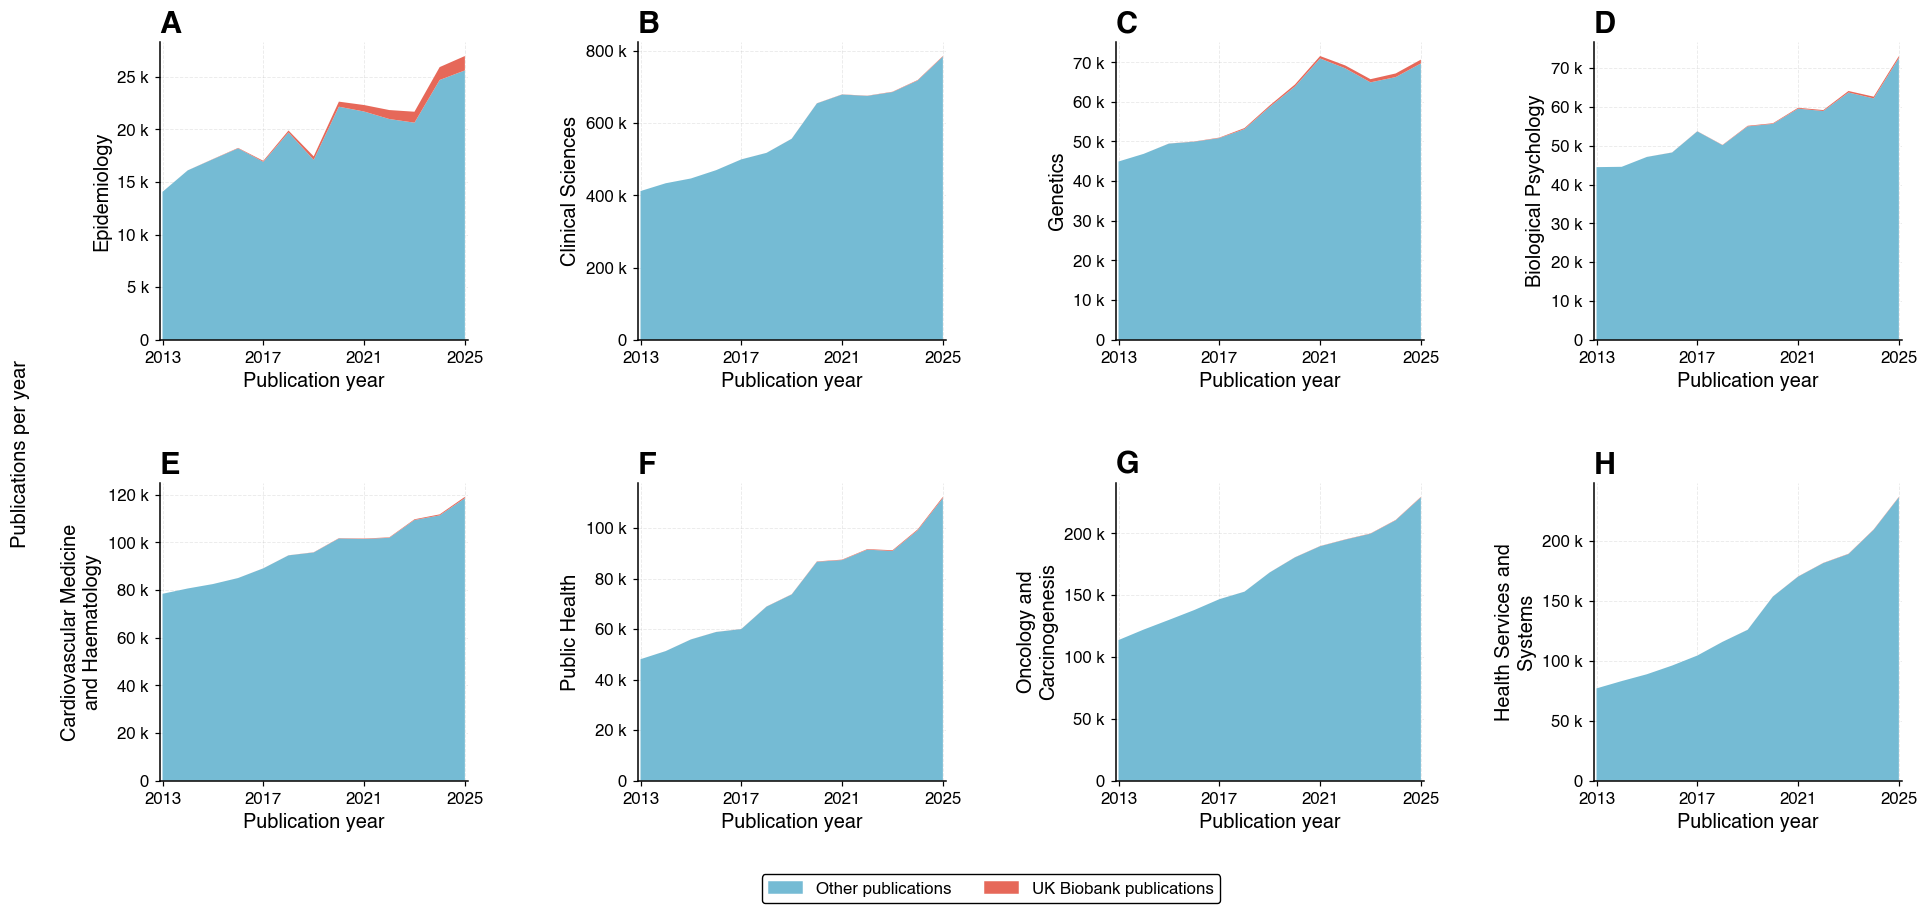

Saved: output/figures/data_analysis/03_academic_impact/01_whole_db_trends_for_L4.pdf
Saved: output/figures/data_analysis/03_academic_impact/01_whole_db_trends_for_L4.png


**Suggested caption:** Annual publication output in the eight leading UK Biobank Fields of Research, shown in panels A-H in field order. Stacked areas partition the whole database into UK Biobank and other publications. A publication can contribute to multiple fields. Counts describe the reference literature, not an estimated effect of UK Biobank on its growth.

In [5]:
fig = Q.whole_database_trends(CTX)
Q.publish(fig, f"01_whole_db_trends_{COL_TYPE}_{LEVEL}{FILE_TAG}", ARTIFACTS)


### 4.2 Chart 2 — What UK Biobank adds, in papers and in share

* **Left** — UK Biobank's own output in each field (absolute count).
* **Right** — that output as a **share of the whole database** in the same field.

UK Biobank is a small slice of a vast literature, so the share is the truer measure of its
footprint than the raw count. Fields are direct-labelled on both panels, and colour follows
the field across the whole notebook.

The left panel comes from the UK Biobank arm alone, so it stays readable even when the
background arm has no usable labels and the right panel is stamped out by the guard.

*Saves as* `02_ukbb_contribution_…`


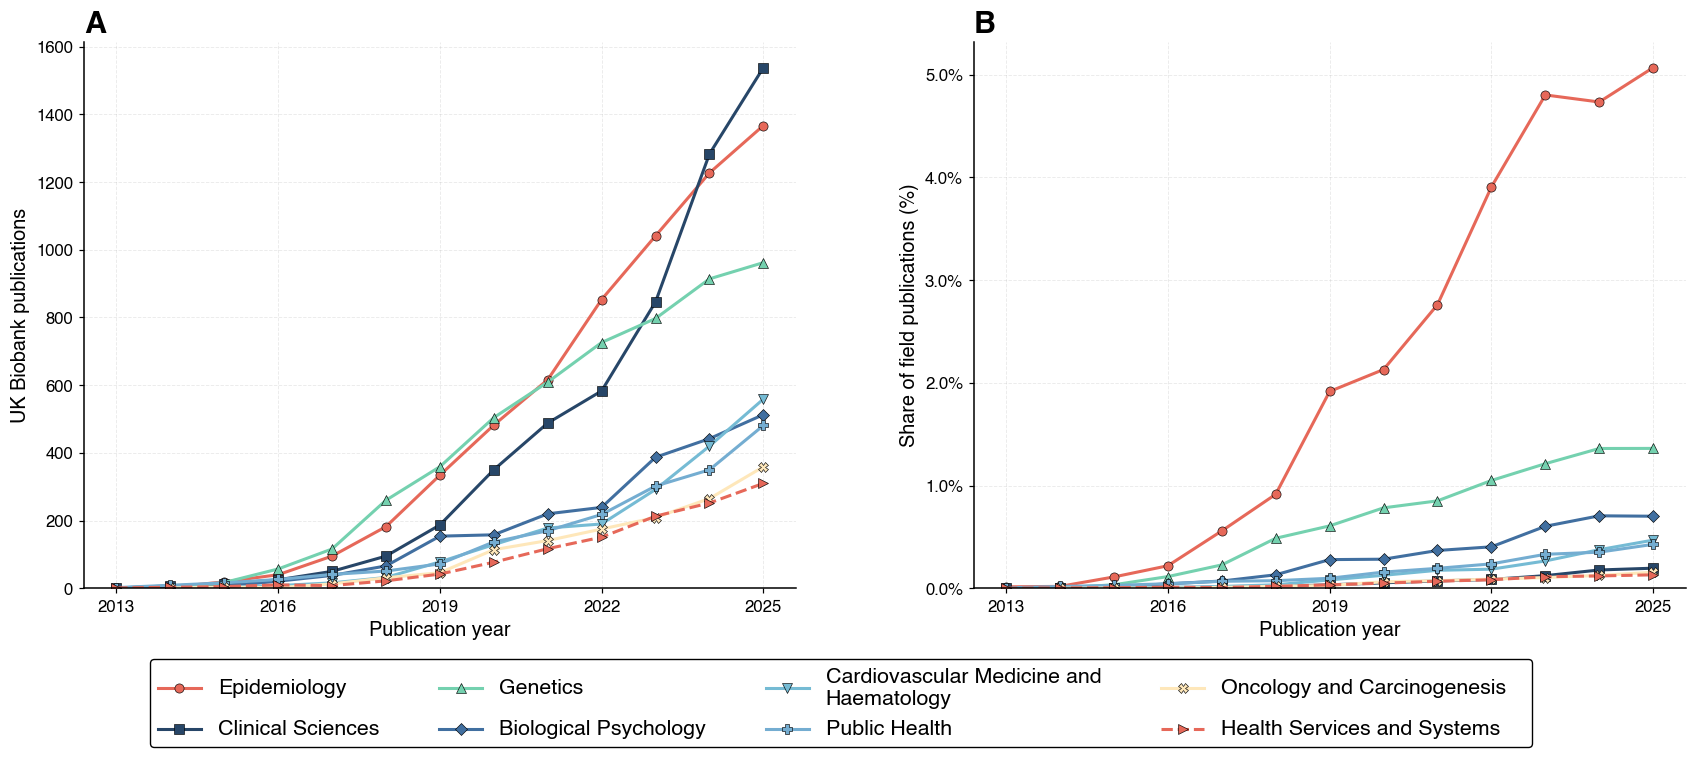

Saved: output/figures/data_analysis/03_academic_impact/02_ukbb_contribution_for_L4_n_papers.pdf
Saved: output/figures/data_analysis/03_academic_impact/02_ukbb_contribution_for_L4_n_papers.png


**Suggested caption:** UK Biobank output in its eight leading Fields of Research. (A) Annual publication counts. (B) UK Biobank publications as a percentage of all publications in the same field and year. Whole counting is used within each field; a paper may appear in more than one field.

In [6]:
fig = Q.publication_contribution(CTX)
Q.publish(fig, f"02_ukbb_contribution_{COL_TYPE}_{LEVEL}{FILE_TAG}_{WEIGHT}", ARTIFACTS)


### 4.3 Marginal annual increase within the study window *(table)*

**Marginal speed** = the slope (papers **added** per year) of a straight-line fit to the
yearly counts over 2013–2025 (`AFTER_WIN`). It is fitted on the **whole database**
and, for context, on UK Biobank's own output. `BEFORE_WIN` is unavailable: pre-2013
publications are excluded, so before-window and acceleration columns remain missing.

> **Caution.** UK Biobank is far too small — a fraction of a percent of any field — to bend
> the whole-database slope, so any acceleration in the `whole_*` columns is a **database-wide
> trend, not something UK Biobank caused**. The `ukbb_after` column is UK Biobank's own pace.
> `whole_*` comes back `<NA>` where the masking guard left that window empty.

**Read `activity_x` before `ukbb_share_%`.** The share answers "how much of this field is UK
Biobank?" and is bounded by UK Biobank's size, so it is small everywhere by construction. The
activity index answers "how much **more** of UK Biobank's work is in this field than the
literature's?" — 1.0 is parity, 3.0 is triple concentration — and that is the question a
funder is actually asking.


In [7]:
print("Pre-2013 comparison unavailable: those years are outside the study window.")
def slope(frame, code, win, value=VALUE):
    if win is None:
        return np.nan
    y0, y1 = win
    s = (frame[(frame.code == code) & frame.year.between(y0, y1)]
         .groupby("year")[value].sum()
         .reindex(range(y0, y1 + 1)).fillna(0.0))
    if (s > 0).sum() < 2:
        return np.nan
    return float(np.polyfit(s.index.values.astype(float), s.values, 1)[0])

rows = []
for code, lab in zip(TOP_CODES, TOP_LABELS):
    wb = slope(whole, code, BEFORE_WIN)
    wa = slope(whole, code, AFTER_WIN)
    accel = wa / wb if (not np.isnan(wb) and not np.isnan(wa) and wb > 0) else np.nan
    rows.append({
        UNIT: lab,
        "whole_before_/yr": wb,
        "whole_after_/yr": wa,
        "acceleration_x": accel,
        "ukbb_after_/yr": slope(ukbb, code, AFTER_WIN),
        f"ukbb_share@{YEAR_MAX}_%": share_at(lab),
        "activity_x": float(ACTIVITY.get(code, np.nan)),
    })

speed = pd.DataFrame(rows).set_index(UNIT)
speed_fmt = speed.copy()
for c in ["whole_before_/yr", "whole_after_/yr", "ukbb_after_/yr"]:
    speed_fmt[c] = speed_fmt[c].round(0).astype("Int64")
speed_fmt["acceleration_x"] = speed_fmt["acceleration_x"].round(2)
speed_fmt[f"ukbb_share@{YEAR_MAX}_%"] = speed_fmt[f"ukbb_share@{YEAR_MAX}_%"].round(2)
speed_fmt["activity_x"] = speed_fmt["activity_x"].round(2)
speed_fmt

Pre-2013 comparison unavailable: those years are outside the study window.


,whole_before_/yr,whole_after_/yr,acceleration_x,ukbb_after_/yr,ukbb_share@2025_%,activity_x
field,,,,,,
Epidemiology,<NA>,932,NaN,145,5.07,12.00
Clinical Sciences,<NA>,33605,NaN,148,0.20,0.86
Genetics,<NA>,2388,NaN,103,1.36,6.20
Biological Psychology,<NA>,2193,NaN,52,0.70,2.42
Cardiovascular Medicine and Haematology,<NA>,3388,NaN,52,0.47,1.84
Public Health,<NA>,5435,NaN,44,0.43,0.93
Oncology and Carcinogenesis,<NA>,9591,NaN,35,0.16,0.74
Health Services and Systems,<NA>,14773,NaN,31,0.13,0.32


### 4.4 Chart 3 — Growth speed of each field, year by year

**Speed** = the annual increase: how many more papers a field gained than the year before
(the first difference of Chart 1's whole-database curve). It is plotted **across** years, per
field, rather than collapsed into a single before/after number (§4.3), so the change in pace
is shown descriptively rather than as a story about a cause.

The dashed line at `UKBB_YEAR` is **only a time reference**: a rise to its right is a
database-wide trend, and UK Biobank — single-digit percent of any field at most — is far too
small to have bent these curves.

*Saves as* `03_growth_speed_…`


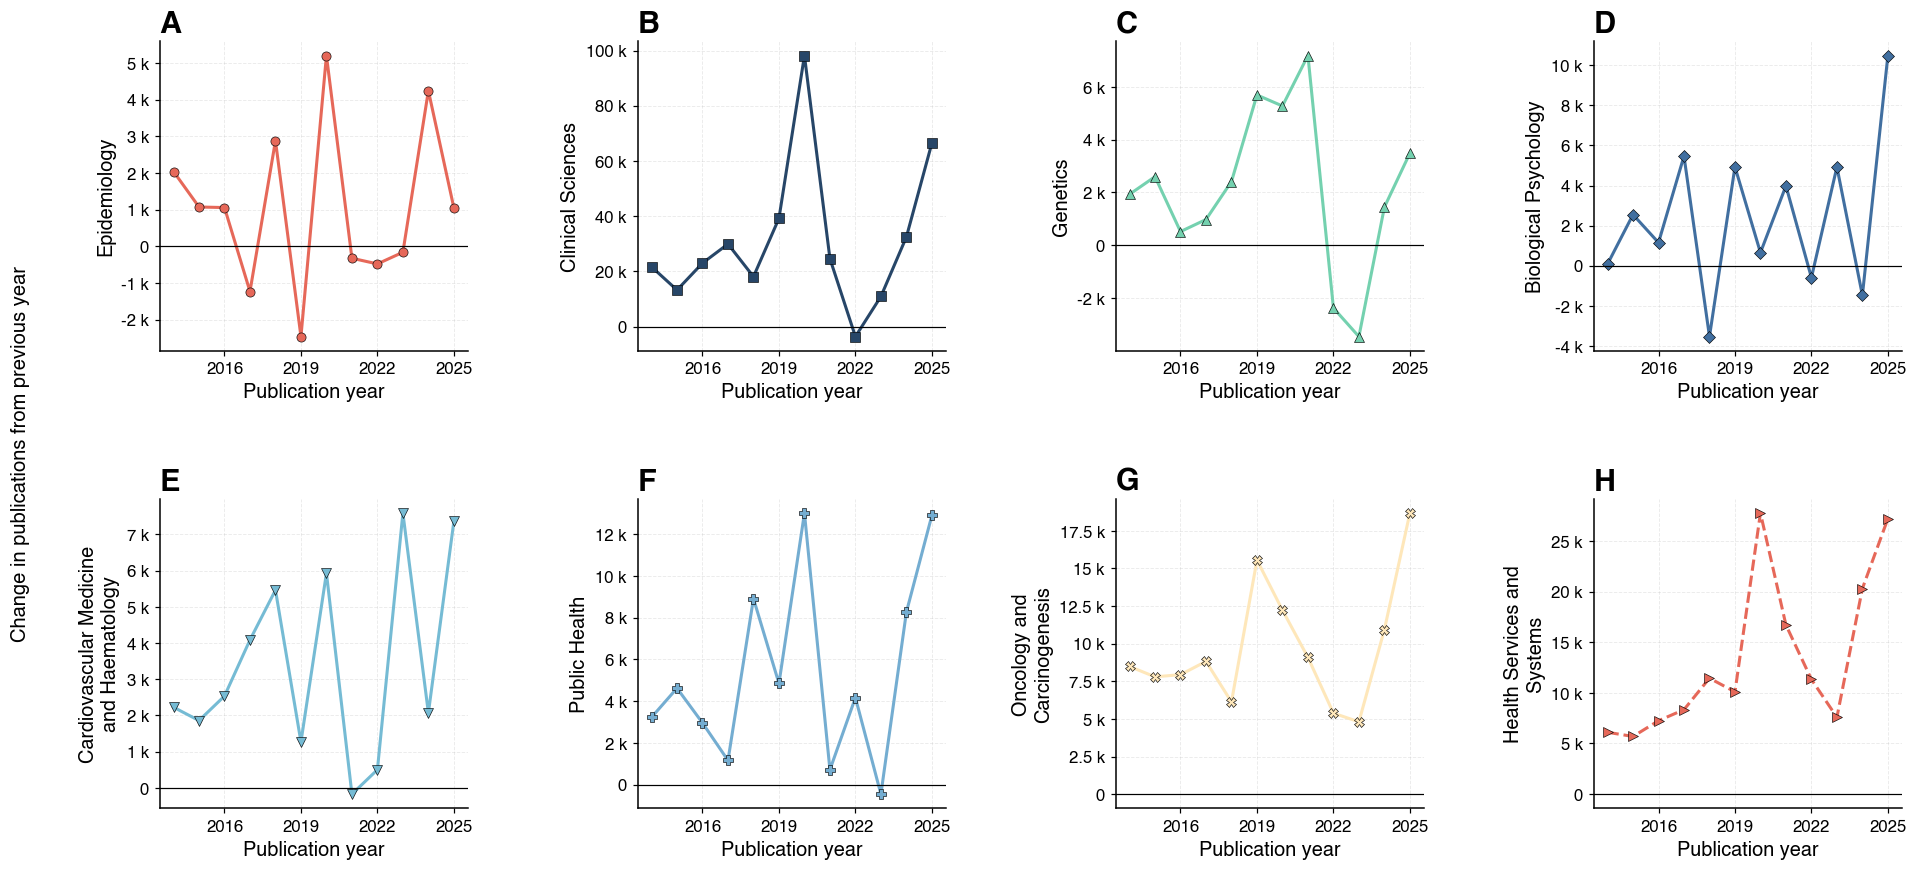

Saved: output/figures/data_analysis/03_academic_impact/03_growth_speed_for_L4.pdf
Saved: output/figures/data_analysis/03_academic_impact/03_growth_speed_for_L4.png


**Suggested caption:** Year-on-year changes in whole-database publication counts for the eight leading UK Biobank fields (A-H). Values are first differences in counts, not percentage growth rates or estimates of UK Biobank's contribution.

In [8]:
fig = Q.annual_growth_speed(CTX)
Q.publish(fig, f"03_growth_speed_{COL_TYPE}_{LEVEL}{FILE_TAG}", ARTIFACTS)


### 4.5 Chart 4 — The activity index: what UK Biobank is disproportionately about

Chart 2's share is bounded by UK Biobank's size, so every field looks tiny there and the
ranking mostly reproduces "which fields are big". The activity index divides that size out:

$$\text{AI}(X)=\frac{\text{UK Biobank's papers in }X\ /\ \text{all UK Biobank papers}}
{\text{database's papers in }X\ /\ \text{all database papers}}$$

**1.0** = UK Biobank works on *X* exactly as much as the literature does, **3.0** = three
times as concentrated, **0.3** = a third. It is a *ratio of shares*, so it is computed on
`n_frac` whatever `WEIGHT` says — the same convention as `ACTIVITY` in the §3 build cell —
and it is measured against whatever `ACTIVITY_BASE` sets (see §2: `within_parent` is the one
that removes "UK Biobank is a biomedical resource" from the comparison).

* **Left** — UK Biobank's biggest fields against parity. Log axis, so 2× and 0.5× sit the
  same distance from the 1.0 line; dot area = UK Biobank papers, so a large dot far to the
  right is both a big and a distinctive body of work.
* **Right** — the same index year by year: is the concentration deepening or fading?
  Field-years carrying fewer than `ACT_MIN_N` UK Biobank papers are dropped — a ratio of
  shares built on a handful of papers is noise, which is most of what 2015 and 2016
  contain even inside the window (63 and 160 UK Biobank papers across 103 fields).

In the historical 2015–2025 calibration, using `within_parent`, Epidemiology read **12.0×** its own division and
**61.4×** against all research — the gap between those two numbers is the whole reason
§2 defaults to `within_parent`.

*Saves as* `04_activity_index_…`


saved output/tables/03_academic_impact/activity_index_top20.csv


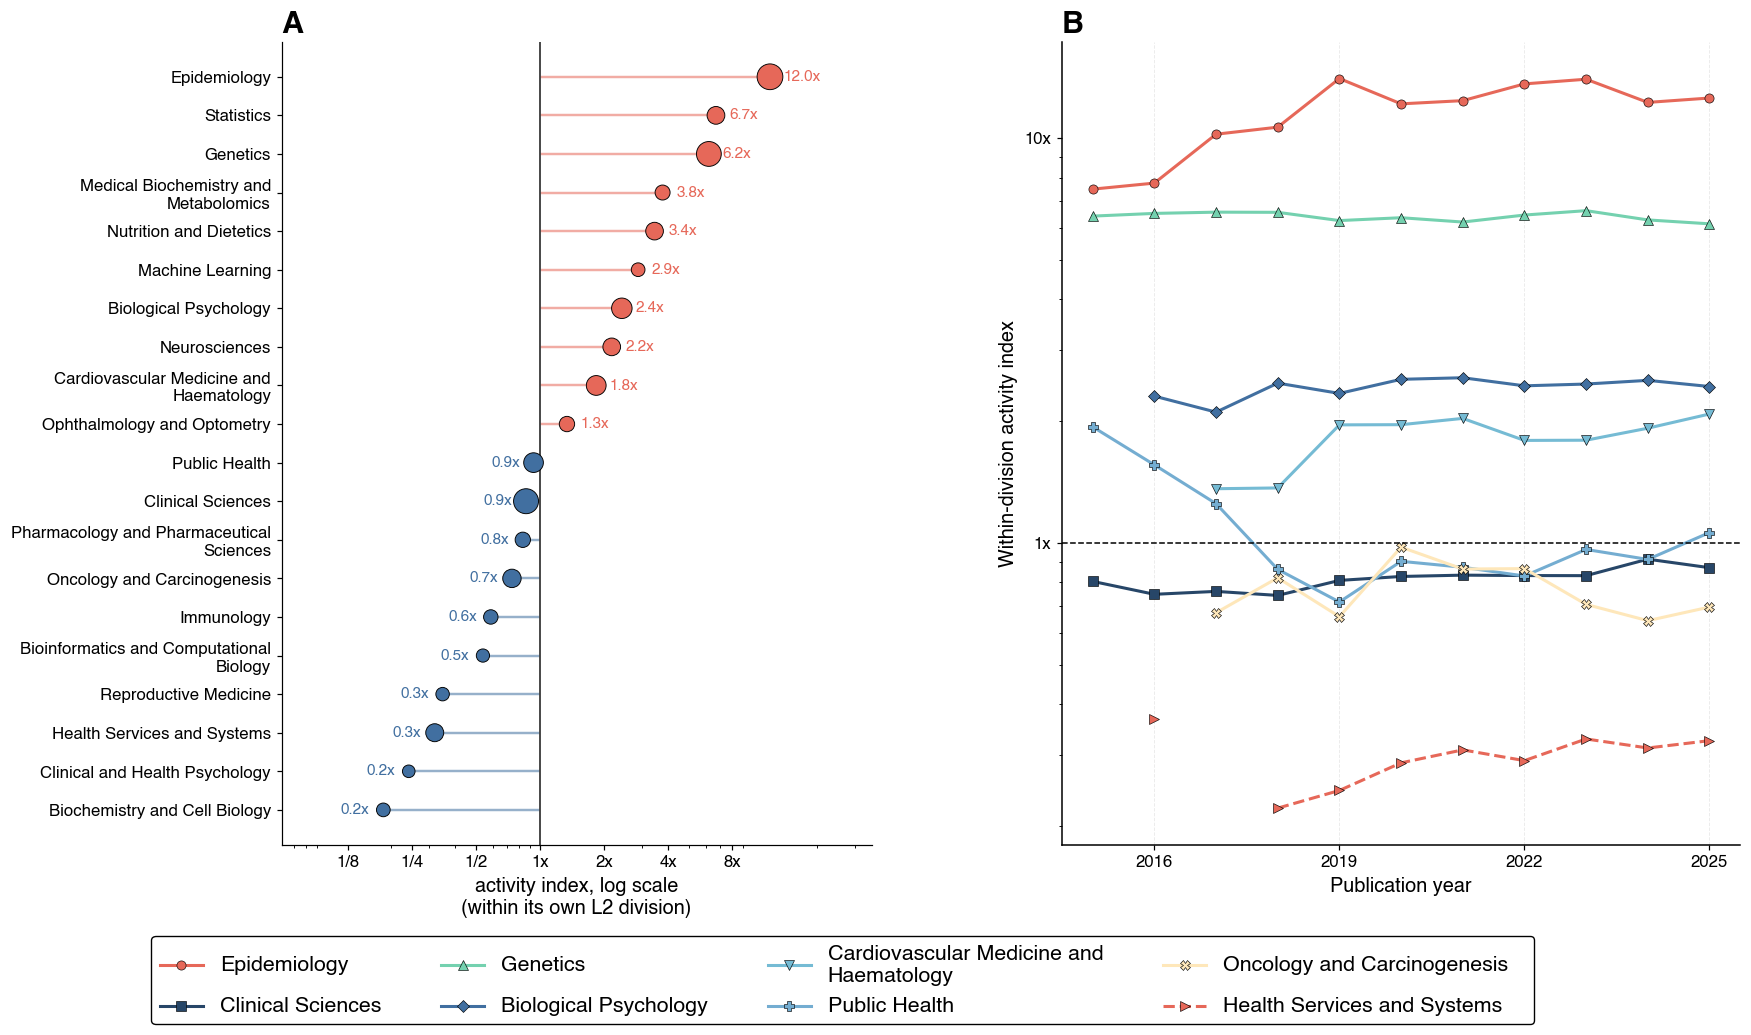

Saved: output/figures/data_analysis/03_academic_impact/04_activity_index_for_L4.pdf
Saved: output/figures/data_analysis/03_academic_impact/04_activity_index_for_L4.png


**Suggested caption:** Research specialisation by field. (A) Within-division activity indices for the 20 largest UK Biobank fields; marker size encodes publication count. (B) Annual activity indices for the leading eight fields, restricted to field-years with at least ten UK Biobank publications. An index of one indicates the same relative concentration as the reference literature.

In [9]:
fig = Q.activity_over_time(CTX)
Q.publish(fig, f"04_activity_index_{COL_TYPE}_{LEVEL}{FILE_TAG}", ARTIFACTS)


## 5. Citation impact — how well that work lands

Volume answered "how much"; this part asks whether UK Biobank's papers are cited more than
the world's papers in the same field and year. Four citation weights are carried through
side by side on this run, because a result that only holds under one of them is a property of the
measure rather than of UK Biobank:

| weight | what it is | what it rewards |
|---|---|---|
| `n_cit` | raw `times_cited` | citation mass — accrues with age, and with citation-heavy fields. **Shares and means only:** it is not year-normalised, so it never becomes an `rci_` ratio (see below) |
| `n_mncs` | `times_cited` ÷ the mean of its own (year, field) | 1.0 = the field's average paper that year. The headline on this run |
| `n_top10f` | top-decile indicator, **per field** | 1.0 if the paper is in the most-cited tenth of its own (year, field), against a cut-off measured by counting |
| `n_top50f` | above-median indicator, per field | 1.0 if it is at or above that (year, field)'s median |
| `n_fcr` | `field_citation_ratio` | field- **and** year-normalised; 1.0 = world average. VM pathway only |
| `n_top10` | top-decile indicator, whole corpus | VM pathway's decile: the most-cited tenth of the (year, type), not of the field |

**Why `n_cit` gets no ratio.** `rci_<w>` pools the whole impact window before taking the two
means, and the arms are not spread over that window alike: UK Biobank's output is still
ramping: in the historical 2015–2025 calibration, **64–78%** of its papers in its top fields are from the last four
years (2022–2025), against **40–49%** of the world's. A weight that accrues with age therefore
meets a far younger population in the numerator than in the denominator, and the ratio comes
out too low — pooled **1.48** against a year-controlled **1.73** for Epidemiology, and
**1.54** against **2.13** for Biological Psychology. Every weight that *does* carry a ratio is normalised
against its own publication year **before** it is aggregated, so the composition cancels.
`n_cit` stays available as a *share* (Chart 7), where numerator and denominator are the same
set of papers and the problem does not arise.

`CITE_HEADLINE` (§2) picks the one the headline panels lead with; `CITE_MIN_DOCS` /
`CITE_MIN_DOCS_YEAR` set how thin a field-window may be before its mean is treated as noise,
and the usable citation window is derived from coverage in §3. §5.1 builds the table, §§5.2–5.4
draw it.


### 5.1 The citation-weighted table — `IMPACT`

`IMPACT` (built in the §3 load cell) carries, per field, over the impact window:

* **`rci_<w>` — relative citation impact.** The mean weight of UK Biobank's papers in *X*
  over the mean weight of the whole database's papers in *X*. **1.0 = cited exactly like
  everyone else's work in the same field.** It is a *mean* over the papers that carried a
  value, which is what lets it survive the two arms being measured to different depths (on
  the VM pathway FCR reaches 97% of the UK Biobank arm and 73% of the background; on this
  one every weight is measured in ~100% of both). Only the weights in `RCI_WEIGHTS` get
  one — `n_cit` does not, for the reason in §5.
* **`act_<w>` — citation activity index.** Chart 4's activity index with citation mass in
  place of paper counts; folds volume and impact together.
* **`activity_x`** — the volume activity index recomputed on the impact window, so all the
  columns describe the same years.

**The pooled figure comes first, deliberately.** Without it a field's 2.5× reads as
remarkable when the whole corpus sits at 2.4× and the field is merely average *for UK
Biobank*.


In [10]:
if not CITE_OK:
    print("no usable citation window — the impact section is skipped")
else:
    _u = ukbb[ukbb.year.between(*CITE_WIN)]
    _w = whole[whole.year.between(*CITE_WIN)]
    # FRAC_SFX is "_frac" on the VM pathway and "" on the API one, where there are no
    # fractional columns to take a mean over — same measure either way.
    _mean = lambda f, wt: f[f"{wt}{FRAC_SFX}"].sum() / f[f"{wt}_docs{FRAC_SFX}"].sum()
    print(f"UK Biobank overall, {CITE_WIN[0]}-{CITE_WIN[1]}, against the whole database"
          f" ({UNIT}-tagged papers):")
    # Every weight gets its two means printed; only the year-normalised ones get the
    # ratio beside them. n_cit's means are worth seeing — they are the arithmetic
    # everything else is built on — but their quotient would compare UK Biobank's
    # recent papers with the world's older ones, so it is withheld rather than shown
    # with a caveat nobody reads. RCI_WEIGHTS is the list that may be divided.
    for wt in WEIGHTS_PRESENT:
        label = {"n_cit": "citations per paper", "n_fcr": "field citation ratio",
                 "n_top10": "share in the top decile",
                 "n_top10f": "share in the field's top decile",
                 "n_top50f": "share above the field median",
                 "n_mncs": "citations vs the field average"}.get(wt, wt)
        fmt = "{:.1%}" if wt.startswith("n_top") else "{:.2f}"
        ratio = (f"= {OVERALL[wt[2:]]:.2f}x" if wt in RCI_WEIGHTS
                 else "(no ratio — not year-normalised)")
        print(f"  {label:31s} UKBB {fmt.format(_mean(_u, wt)):>7s}   whole "
              f"{fmt.format(_mean(_w, wt)):>7s}   {ratio}")

    _head = CITE_HEADLINE[2:]
    cols = (["ukbb_papers", "activity_x"] + [f"rci_{w[2:]}" for w in RCI_WEIGHTS]
            + [f"act_{_head}"])
    impact_fmt = (IMPACT.loc[TOP_CODES, cols]
                  .rename(index=dict(zip(TOP_CODES, TOP_LABELS))).round(2))
    impact_fmt["ukbb_papers"] = impact_fmt.ukbb_papers.round(0).astype("Int64")
    impact_fmt.index.name = UNIT
    print(f"\nUK Biobank's top {TOP_N} {UNIT}s — volume beside impact "
          f"({CITE_WIN[0]}-{CITE_WIN[1]}, {'fractional' if FRAC_OK else 'whole'} counts):")
    display(impact_fmt)


UK Biobank overall, 2015-2025, against the whole database (field-tagged papers):
  citations per paper             UKBB   28.64   whole   12.86   (no ratio — not year-normalised)
  share in the field's top decile UKBB   24.5%   whole    9.6%   = 2.55x
  share above the field median    UKBB   61.5%   whole   46.5%   = 1.32x
  citations vs the field average  UKBB    2.50   whole    1.00   = 2.50x

UK Biobank's top 8 fields — volume beside impact (2015-2025, whole counts):


,ukbb_papers,activity_x,rci_top10f,rci_top50f,rci_mncs,act_mncs
field,,,,,,
Epidemiology,6256,12.00,1.96,1.13,1.80,44.03
Clinical Sciences,5458,0.86,3.12,1.48,2.83,2.09
Genetics,5321,6.20,2.48,1.20,2.72,19.50
Biological Psychology,2244,2.42,2.06,1.10,2.12,6.85
Cardiovascular Medicine and Haematology,1904,1.84,4.30,1.68,4.29,6.76
Public Health,1864,0.93,3.23,1.45,3.11,5.92
Oncology and Carcinogenesis,1359,0.74,1.95,1.37,1.62,1.03
Health Services and Systems,1207,0.32,3.08,1.39,3.04,1.99


### 5.3 Chart 6 — Do the measures agree, and is the impact holding up?

* **Left — agreement.** The same fields under every weight that carries a ratio
  (`RCI_WEIGHTS`). Citation analysis lives or dies on whether a result survives the choice of
  measure: `mncs` divides out the field-year average but is a mean of ratios and so follows
  the biggest hits, while a top-decile rate ignores how big those hits are entirely. Where the
  markers sit together the result is **robust**; where they spread, the ranking is an
  **artefact of the measure** and should be reported as such. The dashed line of each colour
  is UK Biobank's *own* average on that measure — the reference a field should be judged
  against.
* **The spread statistic excludes `n_top50f`.** An above-median rate cannot exceed **2×** by
  construction (the world's rate is 50%), where a decile rate can reach 10× and `mncs` has no
  ceiling at all. Including it would put a floor under every field's "disagreement" that is
  arithmetic rather than evidence. It is still drawn — it just does not vote on whether the
  measures agree.
* **Right — over time.** The headline measure year by year. Impact ratios are noisier than
  volume shares (a field-year needs enough UK Biobank papers to have a mean at all), so thin
  cells are dropped rather than drawn as spikes.

*Saves as* `06_citation_impact_…`


saved output/tables/03_academic_impact/citation_measure_agreement.csv


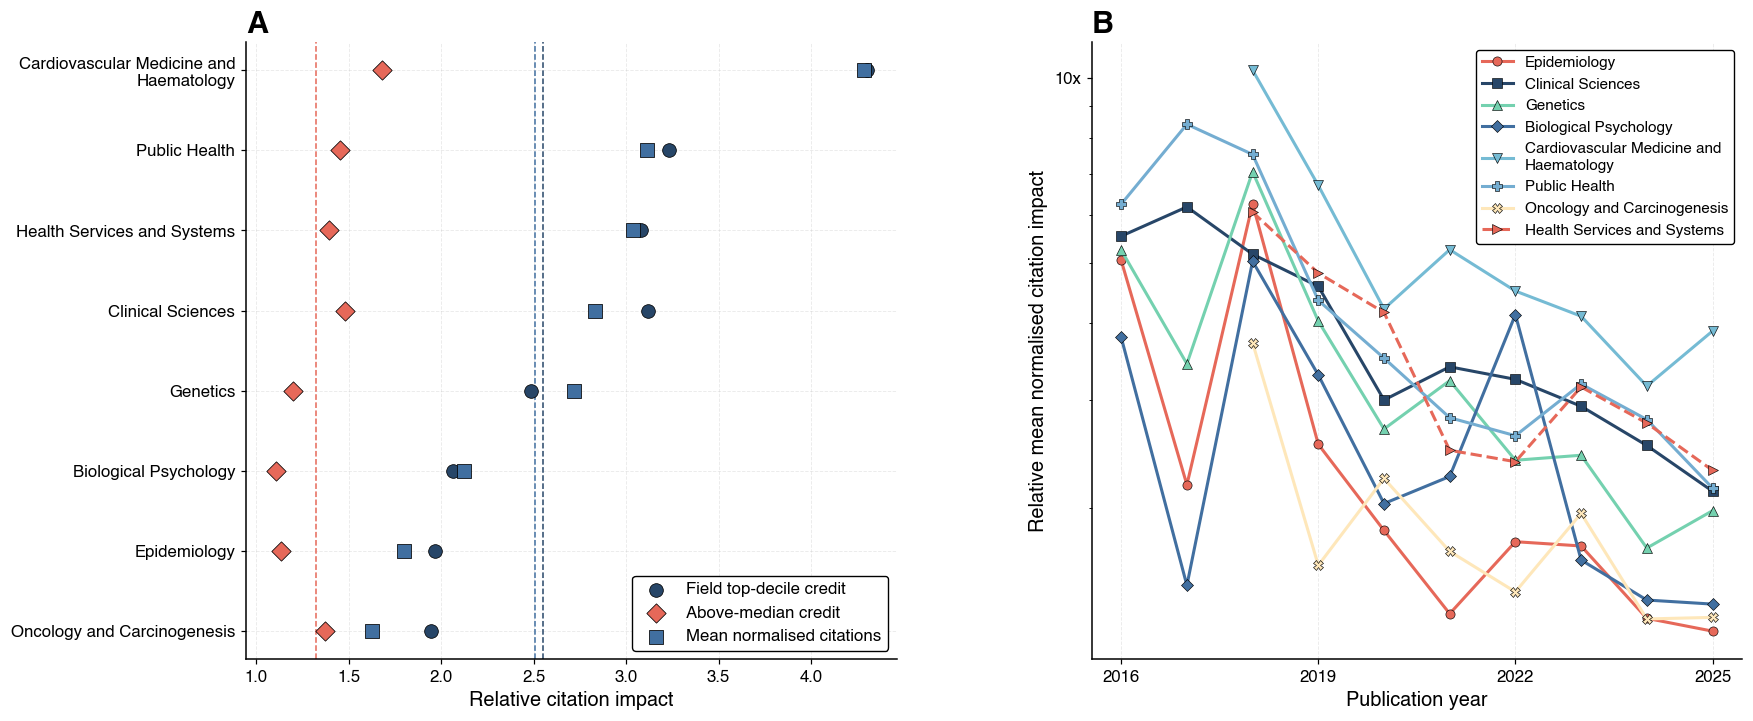

Saved: output/figures/data_analysis/03_academic_impact/06_citation_impact_for_L4_mncs.pdf
Saved: output/figures/data_analysis/03_academic_impact/06_citation_impact_for_L4_mncs.png


**Suggested caption:** Sensitivity of field-level impact to the citation measure. (A) UK Biobank-to-reference ratios under each available normalised measure; dashed lines mark the corresponding overall UK Biobank ratios. (B) Annual relative mean normalised citation impact, requiring at least 20 measured UK Biobank papers per field-year. Missing reference cells are not zeros.

In [11]:
fig = Q.citation_measure_comparison(CTX)
Q.publish(fig, f"06_citation_impact_{COL_TYPE}_{LEVEL}{FILE_TAG}_{CITE_HEADLINE[2:]}", ARTIFACTS)


## 6. Quality bands — the citation cut-offs behind the percentiles

§5 works in ratios. This part puts the same claim back into counts a reader can check a single
paper against: what "top decile" and "above the median" were **worth in citations** in each
year, how much of UK Biobank's footprint in a field clears each bar, and how large the field's
top-cited pool is in the first place.

| | question |
|---|---|
| §6.1 | what were the cut-offs, per (year, field)? |
| Chart 9 | how much of UK Biobank's slice of a field clears the field's median, and its top decile? |
| Chart 9a | were the bands moving, or were the cut-offs? |
| Chart 10 | how big is the field's top-decile pool, and how much of it is UK Biobank's? |

All of §6 needs cut-off columns that only some pathways carry; each cell says what is missing
and skips itself rather than drawing something it cannot support.


### 6.1 The cut-offs behind the quality bands

Charts 9, 9a and 10 all split UK Biobank's papers by where they land in their **own field's**
citation distribution. "Top decile" and "above the median" are percentile language; this cell
puts both back into a unit a reader can check a single paper against, and hands the charts a
per-panel annotation built from it.

* **`thr10`** — the top-decile cut-off for that (year, field): the lowest citation count
  whose at-or-above tail is still inside the field's most-cited tenth. Binary-searched
  cell by cell against the live index (`percentiles --percentiles 10`), so it exists only
  where it was measured. Across UK Biobank's top eight that is **2015 for four fields,
  2016 for two and 2017 for two** — Biological Psychology and Health Services entering in
  2016, Cardiovascular and Oncology in 2017, none of them holding 10 UK Biobank papers in
  a cell before then.
  The retained reference cache has **no 2013 or 2014 threshold rows**. Publications in
  those years remain in the study; these percentile metrics are unavailable for them.

* **`median`** — the field-year median, measured **the same way** (`--percentiles 50`) and
  in the same pass, so it is an **integer** cut-off with the field's own count above it.
  This is the cut-off the `n_top50f` band uses, and because that count is measured, the
  whole-database side of the band is counted rather than imputed at half the field.

  Both cut-offs come back with the share they actually achieved, which is the honest
  reading of how well a cell supports a percentile at all. Over the **213 measured L4
  cells**: the decile lands at **7.30-10.00%** (median 9.77%) — tight, because a tail has
  few ties — while the median lands at **34.23-50.00%** (median **47.69%**), and **49
  cells** fall more than five points short. That is not error: citations are small integers with
  enormous ties, so in a recent year the cut sits at ">= 1 citation" and more than half
  the field is uncited. The count above the cut is still exact; what is approximate is
  calling it the 50th percentile.

  *(Before this was measured, the notebook read `citations_median` off the facet — an
  interpolated percentile that came back fractional (0.1, 0.88, 2.02) in 3,365 of 3,762
  cells, silently cut at `ceil()`, and forced the background arm to assume exactly half
  the field. Cells the percentile pass never reached still fall back to it, and say so.)*

* **`mean`** — the field-year mean, **for scale only**. Citation distributions are skewed hard
  enough that the mean sits near the 70th percentile, not in the middle: in 2020 Epidemiology
  the mean is 27.8 and the measured median is 7.

All three fall steeply with publication year because citations accrue — 2015's tenth-best
Epidemiology paper needed 63 citations, 2025's needs 8. **That is the clock, not a decline in
standards**, and it is exactly why the cut is taken per year.


In [12]:
CUTS = NP._cuts_table(COUNTS_DIR, LEVEL, print)
CTX["CUTS"] = CUTS
if CUTS is not None:
    ARTIFACTS.save_table(CUTS.reset_index(), "field_year_citation_cutoffs.csv")
    display(CUTS.loc[CUTS.index.get_level_values("code").isin(TOP_CODES)].round(2))


  cut-offs: top decile in 213 cell(s), median in 213
saved output/tables/03_academic_impact/field_year_citation_cutoffs.csv


thr10  median  mean_cit  med_pct  median_measured
year code                                                   
2013 3105    NaN   14.70     50.16      NaN            False
     3201    NaN    1.66     17.91      NaN            False
     3202    NaN    4.59     22.77      NaN            False
     3211    NaN    7.55     30.56      NaN            False
     4202    NaN    8.60     35.59      NaN            False
...          ...     ...       ...      ...              ...
2025 3211    8.0    1.00      2.67    48.24             True
     4202    8.0    2.00      2.90    39.06             True
     4203    5.0    1.00      1.72    42.34             True
     4206    6.0    1.00      2.09    48.44             True
     5202    7.0    1.00      2.21    49.03             True

[104 rows x 5 columns]

### Field-year citation cut-offs

Thresholds underlying the quality bands in Figure 5 are shown separately here, without
redrawing the footprint. Missing measurements remain missing. Integer ties can make the
achieved citation share differ from the nominal top 10% or 50%.


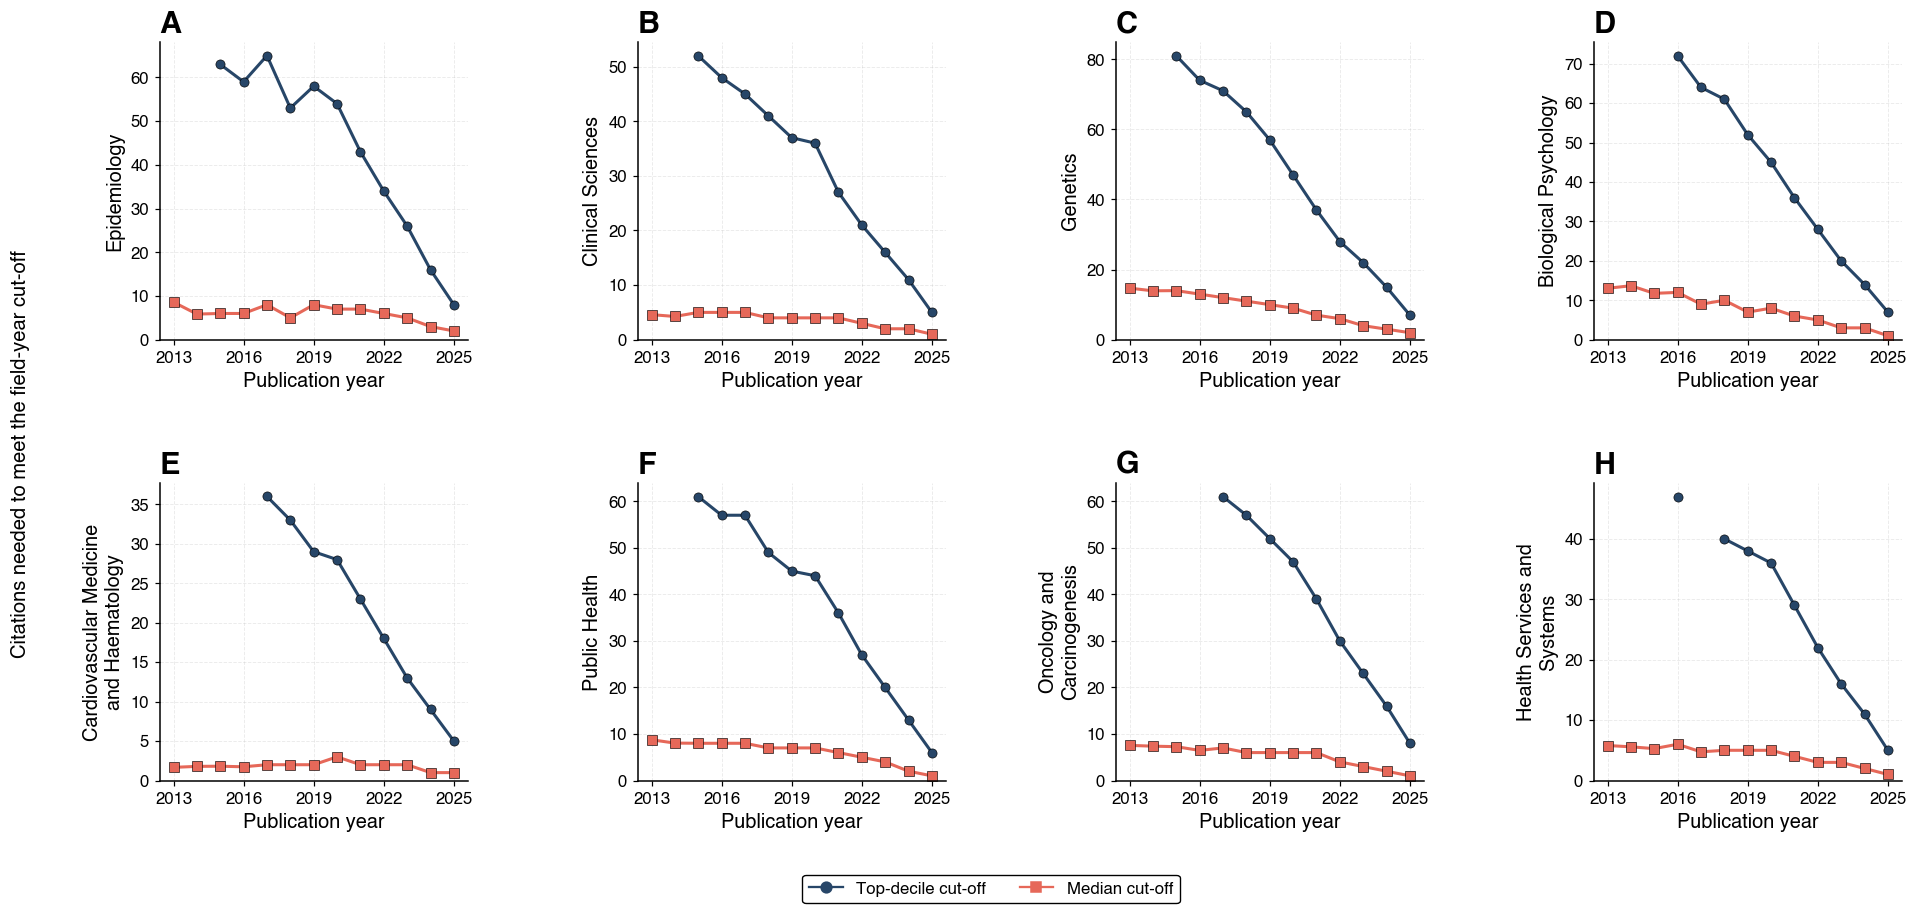

Saved: output/figures/data_analysis/03_academic_impact/09a_footprint_quality_cutoffs_for_L4.pdf
Saved: output/figures/data_analysis/03_academic_impact/09a_footprint_quality_cutoffs_for_L4.png


**Suggested caption:** Citation thresholds underlying the main figure's quality bands, shown for the eight leading fields (A-H). Top-decile cut-offs are measured within each publication year and field. Median cut-offs use the measured threshold where available and the recorded reference median otherwise. Integer citation ties mean that achieved fractions can differ from 10% and 50%. These are snapshot thresholds, not annual citation accrual rates.

In [13]:
fig = Q.citation_cutoffs(CTX, CUTS)
Q.publish(fig, f"09a_footprint_quality_cutoffs_{COL_TYPE}_{LEVEL}{FILE_TAG}", ARTIFACTS)


### 6.4 Chart 10 — The field's top-cited pool, and UK Biobank in it

Chart 9 divides by the **field**: of all the papers published in Epidemiology, what share is UK
Biobank's, and how much of that share cleared each bar? This divides by the **top decile**: of
the papers that made the field's most-cited tenth, how many are there in the first place, and
how many of them are UK Biobank's?

| | |
|---|---|
| **bar height** | every paper in the world that made this field's top decile that year |
| **coloured foot** | UK Biobank's papers among them |
| **line** | that foot as a **percentage** of the bar (right axis) |

The line is not decoration. UK Biobank's share of these pools runs from 0.2% to 10%, a fiftyfold
spread, so at a common bar scale the coloured foot is a visible block in Epidemiology and a
hairline in Clinical Sciences — true, and unreadable. The line puts all eight panels on a scale
where the trend can be read; the foot keeps the reader honest about how small the absolute
contribution still is in the big fields.

**What the bar is and is not.** It is the count of papers at or above the measured decile cut-off
for that (year, field) — so it is ~10% of the field's papers by construction, and its **growth is
the field's growth**, not a change in standards. What moves between panels is the pool's size
(in 2025 Clinical Sciences puts 76,279 papers into its own top tenth; Epidemiology 2,411), which
is the context Chart 9's percentages do not carry. Years before the cut-off was measured are
absent rather than zero.

*Saves as* `10_top_decile_pool_…`


saved output/tables/03_academic_impact/top_decile_pool_summary.csv


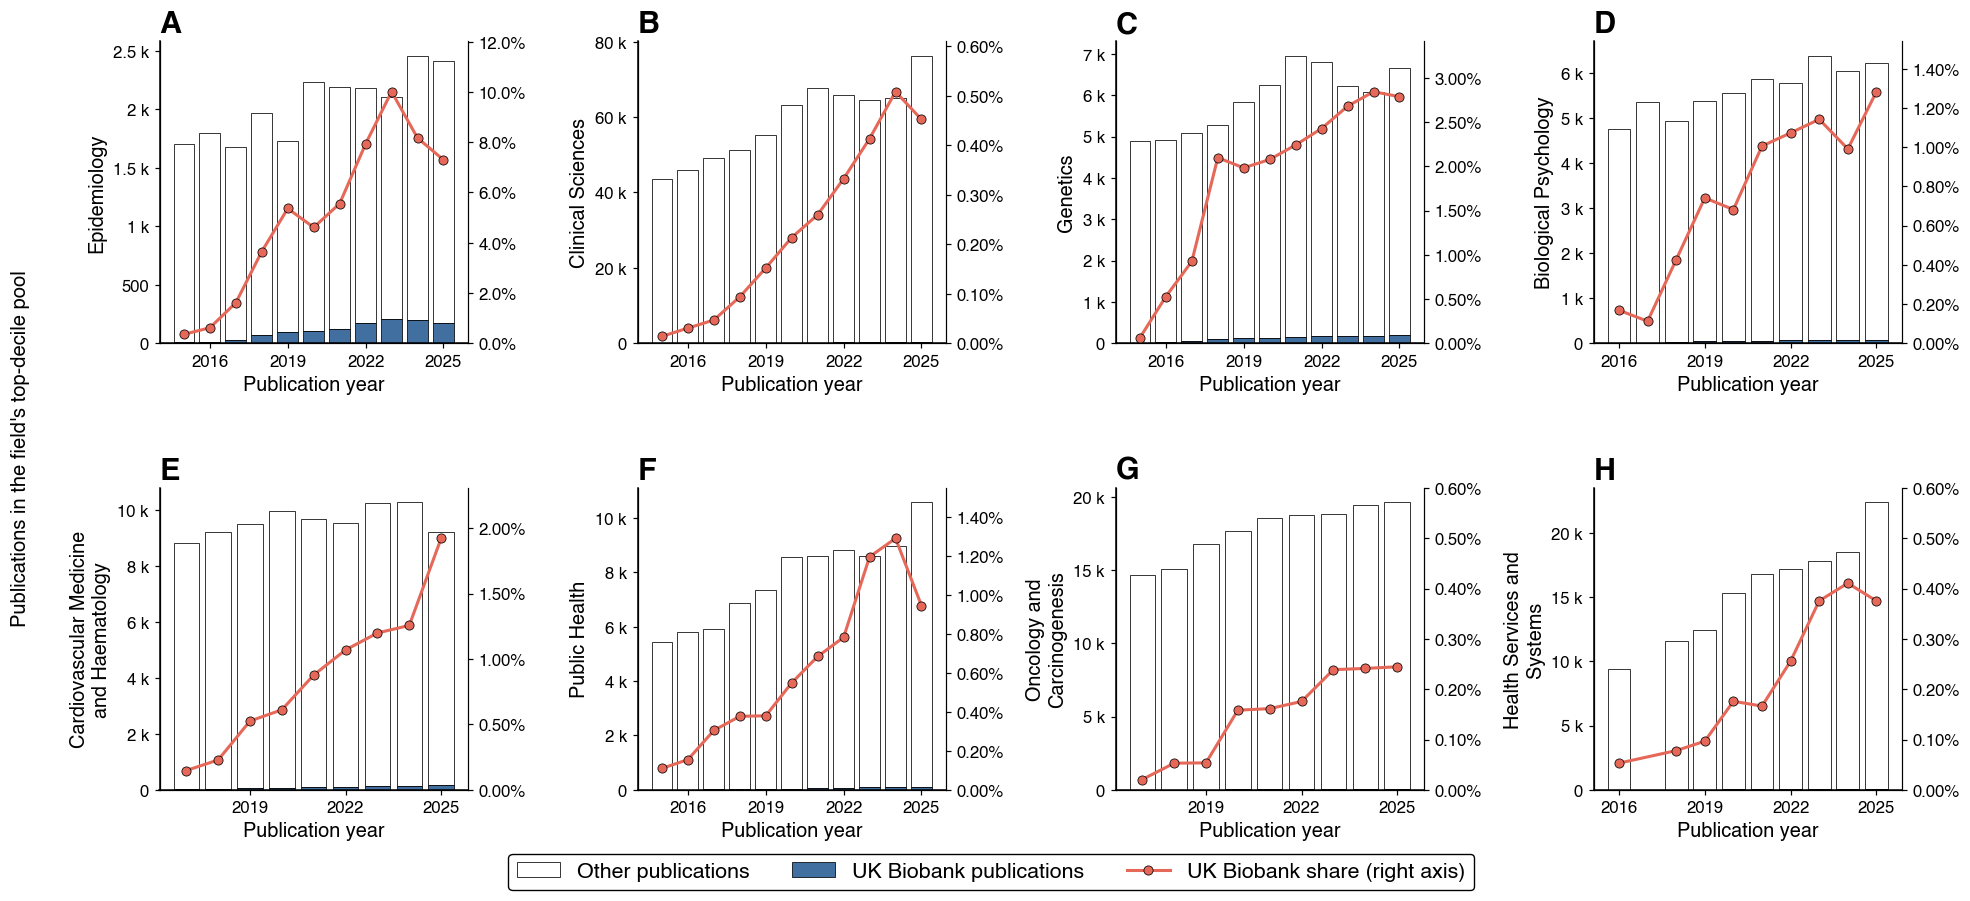

Saved: output/figures/data_analysis/03_academic_impact/10_top_decile_pool_for_L4.pdf
Saved: output/figures/data_analysis/03_academic_impact/10_top_decile_pool_for_L4.png


**Suggested caption:** Size of each field's measured top-decile citation pool and UK Biobank's contribution, across eight leading fields (A-H). Stacked white and blue bars show other and UK Biobank publication counts, respectively; red lines show UK Biobank's percentage of each pool on the right axis. Unmeasured field-year cells remain missing.

In [14]:
fig = Q.top_decile_pool(CTX)
Q.publish(fig, f"10_top_decile_pool_{COL_TYPE}_{LEVEL}{FILE_TAG}", ARTIFACTS)


# Part II: Author-level citation impact

Part I asks what UK Biobank publishes and how well it lands, counted by **field**. This
part asks the same question counted by **person**: who produced that body of
work, how the contribution is spread across the researchers who entered the literature at
different times, and which forms of influence the leading contributors actually hold.

**Two sources, one job each.**

| source | supplies |
|---|---|
| `data/showcase/showcase_plus/showcase_plus_all_endpoints_wide.parquet` (`P.SHOWCASE_PLUS`) | **authorship** — the `authors` field, and nothing else |
| the 03 API pathway (`P.FOR_COUNTS_API`) | **every citation quantity**, through `AI.paper_impact` |

That split is the point of the 2026-08-26 reconcile and is not a convenience.
The parquet also carries `times_cited` and `field_citation_ratio`, and this analysis used to
read them — which put the author arm on a different citation snapshot from every other
number in analysis 03, and on a **top-decile cut-off pooled across all years and fields**.
The pooled cut-off is mostly a measure of paper age (it called 30.8% of 2014's papers
top-decile and 5.4% of 2024's), so an entry-cohort figure built on it rewarded whoever
published earliest. See §4.

**One shared author-impact window: 2015–2025**, normalised within ANZSRC 2020 Fields of
Research at L4. The eligible classified record count is recalculated and checked in §4.
Missing field-year citation references remain unavailable and are reported explicitly.

**Two author figures remain in this part**

1. **Author-entry cohort contribution profile** — the main-paper candidate for Fig. 3a.
2. **Influential-author fingerprint heatmap** — what each leading contributor is ahead on.

The former **author impact portfolio map** is now Figure 5G, built and exported by `05_author_characteristics.ipynb`. Part II still owns its underlying normalized-citation author summary because the cohort and fingerprint analyses use the same table, but it no longer draws or exports a duplicate portfolio figure.

> **Field-level counterpart.** Part I is the field-level arm (ANZSRC Fields of Research).
> Everything the two parts must agree on about
> what a citation weight *is* lives in `src/utils/data_analysis_03_academic_impact_analysis.py`
> — cell-level there, and per paper here via `AI.paper_impact`. The RCDC arm of the same
> analysis is archived at `doc/archive/03_academic_impact_02_rcdc_analysis.ipynb`; the module
> still supports it.


## 0. Inputs expected

**Authorship** — the corpus parquet at `P.SHOWCASE_PLUS`:

```text
data/showcase/showcase_plus/showcase_plus_all_endpoints_wide.parquet
```

Columns read: `id`, `year`, `date`, `authors` (JSON, parsed by `shared_showcase` per D2),
`authors_count`, `title`, `source_title`. Its citation columns are deliberately **not**
read.

**Citations** — three files under `P.FOR_COUNTS_API`, all written by
`src/utils/data_analysis_03_academic_impact_dimensions_api.py`:

| file | supplies |
|---|---|
| `api_ukbb_records.json` | one record per paper: `times_cited`, `field_citation_ratio`, `recent_citations`, `year`, `type`, `category_for_2020` |
| `api_whole.for.parquet` | `mean_cit` per (year, field) — the reference `n_mncs` divides by |
| `field_thresholds.for.csv` | the **measured** top-decile and median cut-offs per (year, field) |

`AI.paper_impact` joins the three and is the only thing in this notebook that decides what a
citation weight means. It raises rather than falling back to the parquet if the record cache
is missing — a silent fallback there is the defect this reconcile removed.

### The measures, over the 2013–2025 publication cohort

| measure | definition |
|---|---|
| `n_mncs` | `times_cited` divided by its own field-year mean; 1.0 is that field's average paper that year |
| `n_top10f` | share of the paper's measured fields in which it clears the field-year decile cut-off |
| `n_top50f` | the same against the measured field-year median |
| `times_cited` | snapshot citation count; used for h-index, i10 and citation totals |

Coverage is printed from the current inputs. Cut-offs were measured only where UK Biobank
had at least 10 papers in a field-year cell, and the retained threshold cache has no
2013–2014 entries. Unmeasured citation metrics remain `NaN`; these publications stay in
the study cohort and are not assigned zero impact. Citation totals retain their snapshot date.


In [15]:
# ============================================================
# 1. Setup, paths, parameters and plotting style
# ============================================================

import json
import re
import sys
import warnings
from pathlib import Path

# Anchor every path on the repo root regardless of where the notebook is launched
# from (repo root, src/, or src/data_analysis/). See shared_paths for the why.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "utils").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import shared_paths as P
from utils.shared_analysis_window import ANALYSIS_START_YEAR, ANALYSIS_END_YEAR, filter_analysis_window
P.bootstrap()
ROOT = P.ROOT

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

# --- the two data sources, and the division of labour between them ---------------
# AUTHORSHIP comes from the corpus parquet: it is the only place the `authors` field
# exists. CITATIONS come from the 03 API pathway, never from the parquet — see §4 and
# AI.paper_impact for why that separation is not optional.
from utils.shared_showcase import load_showcase
from utils import data_analysis_03_academic_impact_analysis as AI

INPUT_PARQUET = P.SHOWCASE_PLUS
COUNTS_DIR = AI.resolve_counts_dir(P.FOR_COUNTS_API)

# --- ANALYSIS PARAMETERS ---------------------------------------------------------
# All primary publication and author-impact cohorts use analysis 03's 2015–2025 window
# (D19), NOT the project-wide corpus floor of 2013: UK Biobank published 27 papers in
# 2014 against 63 in 2015, and `percentiles --min-ukbb 10` measured no 2014 cell in any
# field, so there is nothing to normalise a 2014 paper against.
# Missing field-year citation references remain unmeasured and are reported explicitly.
#
# THIS PART WRITES THE WINDOW INTO input_manifest_author_impact_notebook.csv, and
# `AI.require_author_impact_window` makes Part IV refuse to assemble figures from tables
# built on any other window. Change this and the assembly section
# stops until these tables are rebuilt.
ANALYSIS_MIN = 2015
ANALYSIS_MAX = ANALYSIS_END_YEAR

# The vocabulary the citation weights are normalised within. L4 (fine fields) is what
# the measured decile cut-offs were measured at.
FOR_LEVEL = "L4"

# Entry cohorts preserve the later comparison boundaries; the first includes 2015–2017.
# The first bin opens at ANALYSIS_MIN and its LABEL is built from the same number: the
# label is written into the retained tables as `entry_cohort` and read back as a join key
# by Part IV, so a hand-written year that drifts from the window fails
# there as a missing column rather than as a wrong window.
COHORT_BINS = [
    (ANALYSIS_MIN, 2017, f"{ANALYSIS_MIN}–2017\nfoundational entrants"),
    (2018, 2020, "2018–2020\nexpansion entrants"),
    (2021, 2023, "2021–2023\nconsolidation entrants"),
    (2024, 2025, "2024–2025\nrecent entrants"),
]
cohort_order = [label for _, _, label in COHORT_BINS]


TABLE_DIR = ARTIFACTS.table_dir
TABLE_DIR.mkdir(parents=True, exist_ok=True)
print("Authorship:", P.raw_path(INPUT_PARQUET))
print("Citation references:", P.raw_path(COUNTS_DIR))
print(f"Author analysis window: {ANALYSIS_MIN}-{ANALYSIS_MAX}; FOR {FOR_LEVEL}")


Authorship: data/showcase/showcase_plus/showcase_plus_all_endpoints_wide.parquet
Citation references: data/analysis/academic_impact/for_counts_api
Author analysis window: 2015-2025; FOR L4


In [16]:
# ============================================================
# 2. Helpers
# ============================================================
# WHAT IS NO LONGER HERE, and why:
#
#   infer_col / norm_name_for_col  — fuzzy column matching against a candidate list.
#       The corpus parquet's columns are already canonical (`id`, `year`, `authors`,
#       `times_cited`), so the fuzzy branch never fired usefully and could only ever
#       bind the WRONG column silently — its substring test would have matched
#       `authors_count` for "authors" had the exact name been missing. Columns are
#       named directly in §3 instead.
#   safe_json_loads  — a local JSON/literal parser. D2: nested columns are parsed by
#       `shared_showcase`, which tries JSON first and falls back to a Python literal,
#       so the parquet and any legacy pickle both read. `load_showcase(parse=[...])`
#       does it at load time now.
#   winsorise  — never called.

def clean_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip()


def normalise_name(x):
    """Fold a name to a comparison key: lowercase, punctuation to single spaces.

    This is the FALLBACK author key, used only where Dimensions gives no researcher_id
    (about an eighth of author slots). It is the weakest link in the author-level
    analysis in both directions: it merges two different people who publish under the
    same name, and it splits one person whose name is written two ways.
    """
    x = clean_str(x).lower()
    x = re.sub(r"[^a-z0-9]+", " ", x)
    return re.sub(r"\s+", " ", x).strip()


def mode_or_blank(s):
    s = pd.Series(s).dropna().astype(str)
    s = s[s.str.strip() != ""]
    if s.empty:
        return ""
    m = s.mode()
    return m.iloc[0] if len(m) else s.iloc[0]


def pct_rank_safe(s):
    s = pd.Series(s).replace([np.inf, -np.inf], np.nan).astype(float)
    if s.notna().sum() == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    if s.nunique(dropna=True) <= 1:
        return pd.Series(np.ones(len(s)) * 0.5, index=s.index)
    return s.rank(pct=True, method="average").fillna(0)


def h_index_from_citations(citations):
    vals = sorted([int(float(c)) for c in citations if not pd.isna(c)], reverse=True)
    h = 0
    for i, c in enumerate(vals, start=1):
        if c >= i:
            h = i
        else:
            break
    return h


def i10_index_from_citations(citations):
    vals = [float(c) for c in citations if not pd.isna(c)]
    return int(sum(c >= 10 for c in vals))


In [17]:
# ============================================================
# 3. Load the two sources
# ============================================================
# The corpus parquet supplies AUTHORSHIP and nothing else. Its `times_cited` and
# `field_citation_ratio` columns are deliberately NOT read: see §4.

if not INPUT_PARQUET.exists():
    raise FileNotFoundError(f"Showcase+ publication parquet not found: {INPUT_PARQUET}")

showcase = load_showcase(
    columns=["id", "year", "date", "authors", "authors_count", "title", "source_title"],
    parse=["authors"],          # JSON -> list of dicts, per D2
)
print("Showcase+ full-endpoint parquet:", P.raw_path(INPUT_PARQUET))
print("  shape:", showcase.shape, " unique ids:", showcase.id.nunique())
showcase_eligible = filter_analysis_window(showcase)

# The citation weights, one row per paper, from the same pathway and the same snapshot
# every other number in analysis 03 comes from.
impact = AI.paper_impact(COUNTS_DIR, "for", level=FOR_LEVEL,
                         year_min=ANALYSIS_MIN, year_max=ANALYSIS_MAX)

# An input manifest naming BOTH sources, so any figure can be traced to the files
# behind it rather than to "the corpus".
manifest = pd.DataFrame({
    "role": ["authorship", "citation snapshot", "field reference (mncs)",
             "measured cut-offs (top10f / top50f)", "analysis window", "level"],
    "value": [P.raw_path(INPUT_PARQUET),
              P.raw_path(COUNTS_DIR / "api_ukbb_records.json"),
              P.raw_path(COUNTS_DIR / "api_whole.for.parquet"),
              P.raw_path(COUNTS_DIR / "field_thresholds.for.csv"),
              f"{ANALYSIS_MIN}-{ANALYSIS_MAX}",
              FOR_LEVEL],
})
display(manifest)


Showcase+ full-endpoint parquet: data/showcase/showcase_plus/showcase_plus_all_endpoints_wide.parquet
  shape: (26109, 7)  unique ids: 26109
  paper_impact  22,730 papers 2015-2025 carrying >=1 L4 field (1.49 fields/paper, 113 distinct)
    n_mncs     measured for 100.0% of them
    n_top10f   measured for  98.0% of them; unmeasured records in years [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
    n_top50f   measured for  98.0% of them; unmeasured records in years [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


,role,value
0,authorship,data/showcase/showcase_plus/showcase_plus_all_...
1,citation snapshot,data/analysis/academic_impact/for_counts_api/a...
2,field reference (mncs),data/analysis/academic_impact/for_counts_api/a...
3,measured cut-offs (top10f / top50f),data/analysis/academic_impact/for_counts_api/f...
4,analysis window,2015-2025
5,level,L4


## 4. The paper-level impact table and cohort audit

The study includes publications dated 1 January 2013–31 December 2025. The next cell
recounts the source corpus, resolved API records, publication-window exclusions, and
eligible records with ANZSRC L4 field assignments. It checks the paper-impact table
against that current classified cohort, rather than a count from the former 2015–2025 run.

Records without an L4 field cannot receive an L4-normalised citation score. A paper may
carry a broad L2 division without an L4 field; this is reported separately from missing
classification. Missing field-year references leave citation metrics unmeasured rather
than excluding the publication from the cohort or assigning zero impact. Coverage is
printed for each metric. Retained author tables are reusable only when their manifest
records the same 2013–2025 publication window.


In [18]:
# ============================================================
# 4. The paper-level impact table, and what the window costs
# ============================================================
# THE HEADLINE MEASURE IS n_mncs, and the TOP DECILE IS MEASURED. Both come from
# AI.paper_impact, which is the same arithmetic the field-level notebooks' count tables
# are built from — historical verification over 2015-2025 reproduced the
# fractional columns of counts.for.ukbb.parquet to four decimals.
#
# WHAT THIS REPLACED, because the replacement is the point of the reconcile:
#
#   IMPACT_METRIC used to be `field_citation_ratio`, auto-selected off the parquet and
#   then hard-filtered with `.notna()`. FCR is 96-97% populated for 2014-2024 and
#   0.2% populated for 2025, so that filter quietly cut the analysis to 17,053 papers
#   (65.3% of the corpus) ending in 2024 — while a cohort was labelled "2023-2025
#   recent entrants". n_mncs is computable for 100% of the analysis set, 2025 included.
#
#   The top decile used to be `nanpercentile(FCR, 90)` — ONE cut-off POOLED over every
#   year and every field. That is largely an age variable: it called 30.8% of 2014's
#   papers top-decile and 5.4% of 2024's, so an entry-cohort figure built on it rewarded
#   whoever published earliest. n_top10f is measured per (year, field) by counting
#   against the live index, which is what D9 requires and what Chart 9 in the field
#   notebook draws.
IMPACT_METRIC = "n_mncs"
IMPACT_LABEL = "citations vs the field average"
IMPACT_SHORT = "MNCS"

# Authorship joined to citations. Inner join: a paper needs both to be usable here.
paper_main = (impact.merge(showcase_eligible[["id", "authors", "authors_count", "title",
                                     "source_title"]],
                           on="id", how="inner")
              .rename(columns={"id": "paper_id"}))
paper_main["impact_metric"] = paper_main[IMPACT_METRIC]

# --- the funnel, for the methods section -----------------------------------------
# Recounted from the raw records rather than from paper_main, because paper_main has
# already had every filter applied and so cannot see what they removed — which is the
# entire point of this block. It walks the same steps, in the same order, as §3.1 of
# Part I, §3.1, so the two arms' audits can be read side by
# side and must agree.
_recs = json.loads((COUNTS_DIR / "api_ukbb_records.json").read_text())


def _l4_codes(rec):
    """The 4-digit FOR codes on one record. Dimensions writes the category name as
    '4202 Epidemiology', and a record may carry only its 2-digit division."""
    out = set()
    for c in (rec.get("category_for_2020") or []):
        head = str(c.get("name", "")).split()
        if head and len(head[0]) == 4 and head[0].isdigit():
            out.add(head[0])
    return out


_yrs = pd.Series([r.get("year") for r in _recs])
_n_pq, _n_api = len(showcase), len(_recs)
_below = int((_yrs < ANALYSIS_MIN).sum())
_above = int((_yrs > ANALYSIS_MAX).sum())
_noyear = int(_yrs.isna().sum())
_eligible = filter_analysis_window(pd.DataFrame(_recs))
# The shared guard starts in 2013; this author-impact cohort deliberately starts in
# ANALYSIS_MIN (2015). Apply the narrower window here exactly as paper_impact does.
_eligible = _eligible[
    pd.to_numeric(_eligible["year"], errors="coerce").between(ANALYSIS_MIN, ANALYSIS_MAX)
]
_win = [_recs[i] for i in _eligible.index]
_nocat = [r for r in _win if not r.get("category_for_2020")]
_tagged = [r for r in _win if _l4_codes(r)]
_l2only = len(_win) - len(_tagged) - len(_nocat)


def _line(label, n, base=None, note=""):
    share = f"{n / base:6.2%}" if base else "       "
    print(f"  {label:<48s} {n:>7,}  {share}  {note}")


def _years_note(mask):
    counts = _yrs[mask].value_counts().sort_index()
    return "(" + ", ".join(f"{int(y)}: {n:,}" for y, n in counts.items()) + ")"


print(f"\nUK BIOBANK CORPUS -> AUTHOR-LEVEL ANALYSIS SET "
      f"({ANALYSIS_MIN}-{ANALYSIS_MAX}, FOR {FOR_LEVEL})\n")
_line("papers in the corpus parquet", _n_pq)
_line("records the live index still resolves", _n_api, _n_pq,
      f"({_n_pq - _n_api:,} unresolved: retracted, merged or re-identified)")
print()
# The two tails are separated because they cost wildly different amounts and are
# defended on different grounds: the floor is a methodological choice worth 32 papers,
# the ceiling is a calendar worth 2,670.
_line(f"EXCLUDED  published before {ANALYSIS_MIN}", _below, _n_api,
      _years_note(_yrs < ANALYSIS_MIN))
_line(f"EXCLUDED  published after {ANALYSIS_MAX}", _above, _n_api,
      _years_note(_yrs > ANALYSIS_MAX) + " — a part-year, not a decline")
if _noyear:
    _line("EXCLUDED  no publication year", _noyear, _n_api)
print()
_line(f"IN WINDOW {ANALYSIS_MIN}-{ANALYSIS_MAX}", len(_win), _n_api)
# Split, because these are not the same failure: one is a paper Dimensions never
# classified, the other is a paper it classified only coarsely. The second is by far the
# larger, grows every year, and would mostly return at FOR L2.
_line("  of which: no FOR category at all", len(_nocat), len(_win))
_line(f"  of which: L2 division only, no {FOR_LEVEL} field", _l2only, len(_win))
_line(f"ANALYSIS SET ({FOR_LEVEL}-classified)", len(_tagged), len(_win))
_line("  …with authorship in the parquet", len(paper_main), len(_tagged))
print(f"\n  carrying {paper_main.n_codes.mean():.2f} {FOR_LEVEL} codes per paper, "
      f"{paper_main.authors_count.sum():,.0f} author slots "
      f"(mean {paper_main.authors_count.mean():.1f}, max {paper_main.authors_count.max():,.0f})")
_drop = _n_pq - len(paper_main)
print(f"\n  {_drop:,} of {_n_pq:,} corpus papers ({_drop / _n_pq:.1%}) are not in the "
      f"analysis set; {_above / _drop:.0%} of that is {ANALYSIS_MAX + 1} alone.")

# Verify against the in-window classified records, not a retained 2015–2025 count.
assert len(impact) == len(_tagged), (
    f"Paper impact has {len(impact):,} rows; the {ANALYSIS_MIN}-{ANALYSIS_MAX} "
    f"classified record cohort has {len(_tagged):,}."
)

print(f"\nimpact metric: {IMPACT_METRIC} ({IMPACT_LABEL}); "
      f"1.0 = the average paper of its own field and year")
print(f"top decile:    n_top10f, cut-off measured per (year, {FOR_LEVEL} field) — "
      f"fractional over a paper's fields")
for w in ("n_mncs", "n_top10f", "n_top50f"):
    print(f"  {w:<9s} present for {paper_main[w].notna().mean():6.1%} of the set, "
          f"mean {paper_main[w].mean():.3f}")

display(paper_main[["paper_id", "year", "times_cited", "n_codes",
                    "n_mncs", "n_top10f", "n_top50f"]].head())



UK BIOBANK CORPUS -> AUTHOR-LEVEL ANALYSIS SET (2015-2025, FOR L4)

  papers in the corpus parquet                      26,109           
  records the live index still resolves             26,080  99.89%  (29 unresolved: retracted, merged or re-identified)

  EXCLUDED  published before 2015                       32   0.12%  (2013: 5, 2014: 27)
  EXCLUDED  published after 2025                     2,670  10.24%  (2026: 2,670) — a part-year, not a decline

  IN WINDOW 2015-2025                               23,378  89.64%  
    of which: no FOR category at all                    20   0.09%  
    of which: L2 division only, no L4 field            628   2.69%  
  ANALYSIS SET (L4-classified)                      22,730  97.23%  
    …with authorship in the parquet                 22,730  100.00%  

  carrying 1.49 L4 codes per paper, 267,571 author slots (mean 11.8, max 2,119)

  3,379 of 26,109 corpus papers (12.9%) are not in the analysis set; 79% of that is 2026 alone.

impact metric: 

,paper_id,year,times_cited,n_codes,n_mncs,n_top10f,n_top50f
0,pub.1093055307,2017,87.0,2,3.375779,1.0,1.0
1,pub.1093028109,2017,1.0,1,0.039952,0.0,0.0
2,pub.1093026619,2017,0.0,2,0.000000,0.0,0.0
3,pub.1093026098,2017,0.0,2,0.000000,0.0,0.0
4,pub.1093001260,2017,35.0,1,1.023561,0.0,1.0


In [19]:
# ============================================================
# 5. Explode Dimensions authors and build author-level metrics
# ============================================================
# ONE PLACE THIS NOTEBOOK DELIBERATELY DOES NOT USE A FIELD-NORMALISED MEASURE.
# total_dataset_citations, the h-index and the i10 are raw-citation quantities and stay
# that way — an h-index over MNCS would be a count of papers whose field-relative score
# exceeds their rank, which is not a quantity anybody has a use for. What changed is
# WHICH raw citations: they now come from the API snapshot with everything else, so the
# notebook sits on one read of the index rather than mixing a 2025 parquet with a 2026
# facet. Normalised impact (mean_impact_metric) and the top-decile credit are
# field-and-year normalised, and those are the columns the figures lead with.

def normalise_authors_cell(cell):
    """A Dimensions author cell -> a list of normalised author dicts.

    `cell` arrives already parsed (load_showcase(parse=["authors"])), so this only
    normalises shape. NOTE: the parquet's author dicts have NO `name` key — only
    `first_name` / `last_name` — so the join below is load-bearing, not a fallback.
    """
    if isinstance(cell, dict):
        cell = [cell]
    if not isinstance(cell, list):
        return []

    authors = []
    for a in cell:
        if isinstance(a, dict):
            first = clean_str(a.get("first_name", a.get("first", "")))
            last = clean_str(a.get("last_name", a.get("last", "")))
            name = clean_str(a.get("name", " ".join([first, last]).strip()))
            rid = clean_str(a.get("researcher_id", ""))
            if not rid and isinstance(a.get("researcher_ids"), list) and a.get("researcher_ids"):
                rid = clean_str(a.get("researcher_ids")[0])
            if not first and name:
                first = name.split()[0]
            authors.append({"name": name, "first_name": first,
                            "last_name": last, "researcher_id": rid})
        elif isinstance(a, str):
            name = a.strip()
            authors.append({"name": name,
                            "first_name": name.split()[0] if name else "",
                            "last_name": "", "researcher_id": ""})
    return [a for a in authors if a.get("name") or a.get("researcher_id")]


# --- explode --------------------------------------------------------------------
# author_key is Dimensions' researcher_id where there is one (about 88% of author
# slots) and a normalised name otherwise. The name fallback both over- and
# under-merges (see normalise_name); it is the analysis's weakest link and every
# author-level count below inherits its error.
author_rows = []
for r in tqdm(paper_main.itertuples(index=False), total=len(paper_main),
              desc="Exploding authors"):
    authors = normalise_authors_cell(r.authors)
    if not authors:
        continue
    n_authors = len(authors)
    for pos, a in enumerate(authors, start=1):
        rid = clean_str(a.get("researcher_id", ""))
        name = clean_str(a.get("name", ""))
        author_key = rid if rid.startswith("ur.") else normalise_name(name)
        if not author_key:
            continue
        author_rows.append({
            "paper_id": r.paper_id,
            "author_position": pos,
            "n_authors": n_authors,
            "is_first_author": pos == 1,
            "is_last_author": pos == n_authors,
            "author_name": name,
            "first_name": clean_str(a.get("first_name", "")),
            "last_name": clean_str(a.get("last_name", "")),
            "researcher_id": rid,
            "author_key": author_key,
            "year": int(r.year),
            "times_cited": float(r.times_cited),
            "recent_citations": r.recent_citations,
            "field_citation_ratio": r.field_citation_ratio,
            "n_mncs": r.n_mncs,
            "n_top10f": r.n_top10f,
            "n_top50f": r.n_top50f,
            "impact_metric": r.impact_metric,
        })

author_long = pd.DataFrame(author_rows)
if author_long.empty:
    raise ValueError("No authors could be parsed from the author column.")

# Deduplicate within paper-author in case one paper lists the same person twice.
author_paper = author_long.drop_duplicates(["author_key", "paper_id"]).copy()
author_paper["author_name_clean"] = author_paper["author_name"].fillna("").astype(str).str.strip()

# --- co-author credit ------------------------------------------------------------
# Each co-author receives 1/n_authors of the paper and of its citations. The
# top-decile credit follows the same rule, but on a FRACTIONAL indicator: n_top10f is
# the share of the paper's measured fields in which it cleared the decile, so a paper
# top-decile in one of its two fields hands its authors half the credit rather than
# all of it. That is the same weighting the field-level count tables use.
_share = 1 / author_paper["n_authors"].clip(lower=1)
author_paper["fractional_paper_credit"] = _share
author_paper["fractional_citation_credit"] = author_paper["times_cited"] * _share
author_paper["fractional_top_decile_credit"] = author_paper["n_top10f"].fillna(0.0) * _share
author_paper["leadership_author_credit"] = (author_paper["is_first_author"].astype(int)
                                            + author_paper["is_last_author"].astype(int))

# --- author-level summary ---------------------------------------------------------
base = (
    author_paper.groupby("author_key")
    .agg(
        author_name=("author_name_clean", mode_or_blank),
        researcher_id=("researcher_id", mode_or_blank),
        showcase_paper_count=("paper_id", "nunique"),
        fractional_paper_credit=("fractional_paper_credit", "sum"),
        total_dataset_citations=("times_cited", "sum"),
        fractional_citation_credit=("fractional_citation_credit", "sum"),
        mean_dataset_citations=("times_cited", "mean"),
        median_dataset_citations=("times_cited", "median"),
        mean_field_citation_ratio=("field_citation_ratio", "mean"),
        mean_impact_metric=("n_mncs", "mean"),
        median_impact_metric=("n_mncs", "median"),
        # A sum of fractions, not a count of papers — hence the rename. A paper that
        # cleared the decile in one of two fields contributes 0.5.
        top_decile_credit=("n_top10f", "sum"),
        above_median_credit=("n_top50f", "sum"),
        # How many of the author's papers had a MEASURED cut-off to be judged against.
        # A cut-off exists only where UK Biobank had >= 10 papers in the (year, field),
        # so this is the denominator top_decile_share must use — not the paper count.
        top_decile_measured_papers=("n_top10f", "count"),
        fractional_top_decile_credit=("fractional_top_decile_credit", "sum"),
        first_author_paper_count=("is_first_author", "sum"),
        last_author_paper_count=("is_last_author", "sum"),
        leadership_author_credit=("leadership_author_credit", "sum"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
)

metric_rows = []
for key, g in author_paper.groupby("author_key"):
    cites = pd.to_numeric(g["times_cited"], errors="coerce").fillna(0).tolist()
    metric_rows.append({
        "author_key": key,
        "showcase_h_index": h_index_from_citations(cites),
        "showcase_i10_index": i10_index_from_citations(cites),
    })
author_summary = base.merge(pd.DataFrame(metric_rows), on="author_key", how="left")

author_summary["active_span_years"] = (author_summary["last_year"]
                                       - author_summary["first_year"] + 1)
author_summary["leadership_share"] = (
    author_summary["first_author_paper_count"] + author_summary["last_author_paper_count"]
) / author_summary["showcase_paper_count"].clip(lower=1)
# Divided by the MEASURED papers, so an author whose fields were never thresholded is
# NaN here rather than 0 — "we did not look" is not "did not make it".
author_summary["top_decile_share"] = (
    author_summary["top_decile_credit"]
    / author_summary["top_decile_measured_papers"].replace(0, np.nan))

# --- entry cohorts ----------------------------------------------------------------
def assign_entry_cohort(y):
    if pd.isna(y):
        return np.nan
    y = int(y)
    for lo, hi, label in COHORT_BINS:
        if lo <= y <= hi:
            return label
    return np.nan


author_summary["entry_cohort"] = author_summary["first_year"].apply(assign_entry_cohort)
author_paper = author_paper.merge(author_summary[["author_key", "entry_cohort"]],
                                  on="author_key", how="left")

# --- composite influence score ----------------------------------------------------
# The weights are unchanged by the metric swap: every term is a PERCENTILE RANK, so
# replacing FCR with MNCS re-orders the ranks without disturbing how they are combined.
score_terms = {
    "total citations": 0.26 * pct_rank_safe(np.log1p(author_summary["total_dataset_citations"])),
    "fractional citations": 0.20 * pct_rank_safe(np.log1p(author_summary["fractional_citation_credit"])),
    "Showcase+ h-index": 0.20 * pct_rank_safe(author_summary["showcase_h_index"]),
    f"mean {IMPACT_SHORT}": 0.16 * pct_rank_safe(author_summary["mean_impact_metric"]),
    "leadership authorships": 0.12 * pct_rank_safe(author_summary["leadership_author_credit"]),
    "active span": 0.06 * pct_rank_safe(author_summary["active_span_years"]),
}
author_summary["ukb_influence_score"] = 100 * sum(score_terms.values())

author_summary = author_summary.sort_values(
    ["ukb_influence_score", "showcase_h_index", "total_dataset_citations"],
    ascending=False,
).reset_index(drop=True)

# --- export ------------------------------------------------------------------------
author_long.to_csv(TABLE_DIR / "author_long_all_parsed_rows.csv", index=False)
author_paper.to_csv(TABLE_DIR / "author_paper_fractional_credit_table.csv", index=False)
author_summary.to_csv(TABLE_DIR / "author_summary_with_impact_metrics.csv", index=False)
author_summary.sort_values("showcase_paper_count", ascending=False).to_csv(
    TABLE_DIR / "top_authors_by_most_ukb_papers.csv", index=False)
author_summary.sort_values("ukb_influence_score", ascending=False).to_csv(
    TABLE_DIR / "top_authors_by_ukb_influence_score.csv", index=False)
try:
    author_summary.to_excel(TABLE_DIR / "author_summary_with_impact_metrics.xlsx", index=False)
except Exception as e:
    print("Excel export skipped:", e)

print("Author-slot rows parsed:  ", f"{len(author_long):,}")
print("Author-paper rows (dedup):", f"{len(author_paper):,}")
print("Distinct authors:         ", f"{len(author_summary):,}",
      f"({author_summary.researcher_id.str.startswith('ur.').mean():.1%} keyed on a "
      f"researcher_id, the rest on a normalised name)")
print("Recurrent authors (>=5 papers):", f"{int((author_summary.showcase_paper_count >= 5).sum()):,}")
print("Authors with >=1 measured top-decile cell:",
      f"{int((author_summary.top_decile_measured_papers > 0).sum()):,}")

display(author_summary.head(25))

# Publish the cohort manifest only after the author tables have been rebuilt.
manifest.to_csv(TABLE_DIR / "input_manifest_author_impact_notebook.csv", index=False)

for name in (
    "author_long_all_parsed_rows.csv", "author_paper_fractional_credit_table.csv",
    "author_summary_with_impact_metrics.csv", "input_manifest_author_impact_notebook.csv",
):
    ARTIFACTS._register(ARTIFACTS.table_paths, TABLE_DIR / name)


Exploding authors:   0%|          | 0/22730 [00:00<?, ?it/s]

Author-slot rows parsed:   267,468
Author-paper rows (dedup): 266,131
Distinct authors:          88,662 (77.0% keyed on a researcher_id, the rest on a normalised name)
Recurrent authors (>=5 papers): 11,030
Authors with >=1 measured top-decile cell: 87,596


,author_key,author_name,researcher_id,showcase_paper_count,fractional_paper_credit,total_dataset_citations,fractional_citation_credit,mean_dataset_citations,median_dataset_citations,mean_field_citation_ratio,mean_impact_metric,median_impact_metric,top_decile_credit,above_median_credit,top_decile_measured_papers,fractional_top_decile_credit,first_author_paper_count,last_author_paper_count,leadership_author_credit,first_year,last_year,showcase_h_index,showcase_i10_index,active_span_years,leadership_share,top_decile_share,entry_cohort,ukb_influence_score
0,ur.0641770103.91,Rory Collins,ur.0641770103.91,49,3.114371,25412.0,1612.780772,518.612245,26.0,110.682326,23.721565,2.969556,25.500000,35.500000,47,1.263811,0,5,5,2015,2025,25,34,11,0.102041,0.542553,2015–2017\nfoundational entrants,98.633744
1,ur.01371335603.13,Peter Donnelly,ur.01371335603.13,18,1.747667,11833.0,698.974993,657.388889,88.0,124.635000,27.048916,3.856398,10.000000,13.500000,18,1.056724,0,6,6,2016,2025,12,12,10,0.333333,0.555556,2015–2017\nfoundational entrants,98.438079
2,ur.014132776271.93,Adrian Cortes,ur.014132776271.93,22,2.015942,11952.0,650.185372,543.272727,16.0,91.860000,22.819085,1.297698,8.000000,15.333333,21,0.547656,4,1,5,2016,2025,12,12,10,0.227273,0.380952,2015–2017\nfoundational entrants,98.245934
3,ur.012100033157.47,Lloyd T. Elliott,ur.012100033157.47,17,1.604681,12610.0,823.596046,741.764706,39.0,124.598125,28.638120,3.338118,9.000000,13.000000,17,0.831918,2,2,4,2017,2025,11,12,9,0.235294,0.529412,2015–2017\nfoundational entrants,98.228677
4,ur.0627601545.87,Paul M. Matthews,ur.0627601545.87,61,5.964912,22293.0,1165.968231,365.459016,32.0,79.500566,16.520300,2.566997,28.666667,41.000000,56,1.820387,1,10,11,2015,2025,31,39,11,0.180328,0.511905,2015–2017\nfoundational entrants,98.169193
5,ur.01225067535.64,Olivier Delaneau,ur.01225067535.64,30,4.280384,13899.0,907.610026,463.300000,13.0,89.515000,18.105128,1.918303,14.333333,23.000000,30,1.631534,4,12,16,2015,2025,15,16,11,0.533333,0.477778,2015–2017\nfoundational entrants,98.161997
6,ur.014735204720.83,Jonathan Marchini,ur.014735204720.83,54,5.911600,21484.0,1206.499822,397.851852,26.0,66.835102,16.329504,2.943089,30.000000,40.500000,53,2.645017,0,15,15,2015,2025,26,33,11,0.277778,0.566038,2015–2017\nfoundational entrants,98.154621
7,ur.0577003004.68,Naomi Allen,ur.0577003004.68,102,12.215923,34327.0,2283.794502,336.539216,21.5,66.119149,15.102137,1.570922,38.500000,71.000000,99,3.574779,3,21,24,2015,2025,38,65,11,0.235294,0.388889,2015–2017\nfoundational entrants,98.130146
8,ur.010254226477.98,Cathie Sudlow,ur.010254226477.98,70,6.227241,26983.0,1665.637156,385.471429,38.5,70.846667,15.084451,2.409149,34.166667,52.833333,66,2.471749,1,18,19,2015,2025,35,49,11,0.271429,0.517677,2015–2017\nfoundational entrants,98.108987
9,ur.01215063233.82,Christian Benner,ur.01215063233.82,24,1.809263,7828.0,337.970566,326.166667,86.5,73.236818,22.014204,5.766377,15.500000,21.166667,24,0.860787,3,0,3,2017,2025,17,18,9,0.125000,0.645833,2015–2017\nfoundational entrants,98.041540


saved output/tables/03_academic_impact/fig3a_author_entry_cohort_contribution_shares.csv
saved output/tables/03_academic_impact/fig3a_author_entry_cohort_contribution_raw.csv


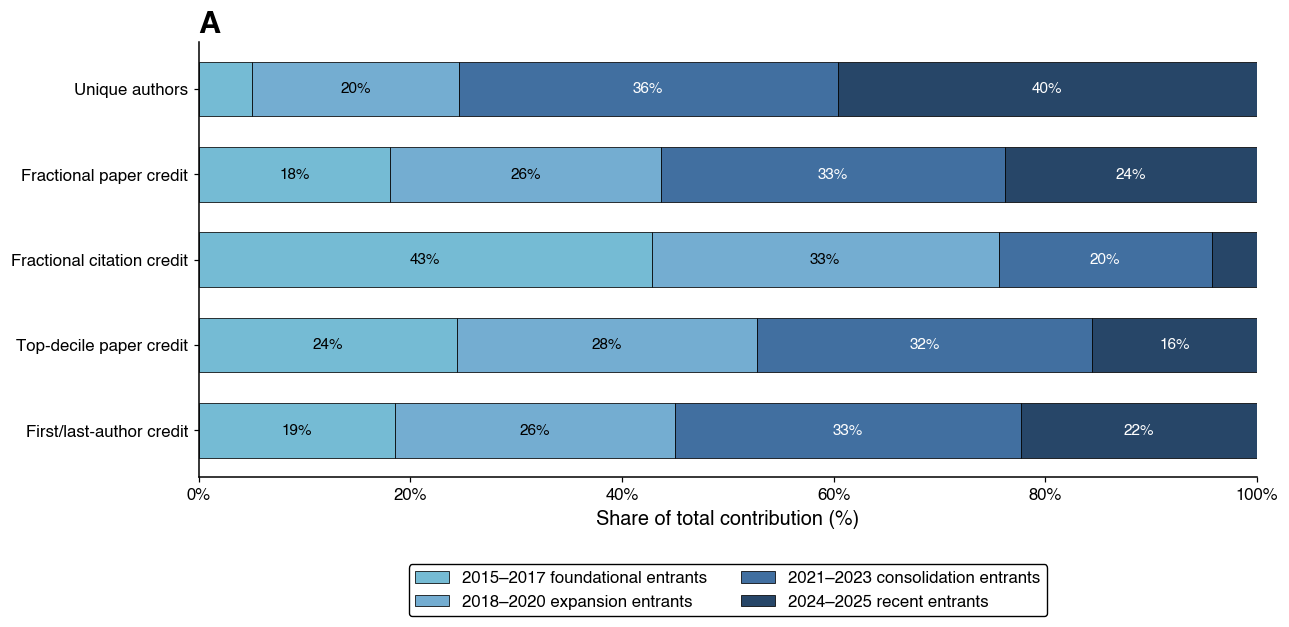

Saved: output/figures/data_analysis/03_academic_impact/fig3a_author_entry_cohort_academic_impact_profile.pdf
Saved: output/figures/data_analysis/03_academic_impact/fig3a_author_entry_cohort_academic_impact_profile.png


**Suggested caption:** Contributions to UK Biobank research by author-entry cohort, 2015-2025. Authors are grouped by their first observed publication within this window. Rows show each cohort's share of authors, fractional papers, fractional citations, field-year top-decile credit and first/last-author credit. Author keys retain the original name-based fallback when a researcher identifier is unavailable; this is not the resolved-only author population analysed in the author-characteristics notebook.

In [20]:
fig = Q.author_cohort_profile(author_summary, author_paper, cohort_order)
Q.publish(fig, "fig3a_author_entry_cohort_academic_impact_profile", ARTIFACTS)


saved output/tables/03_academic_impact/fig_author_influence_fingerprint_top_authors.csv


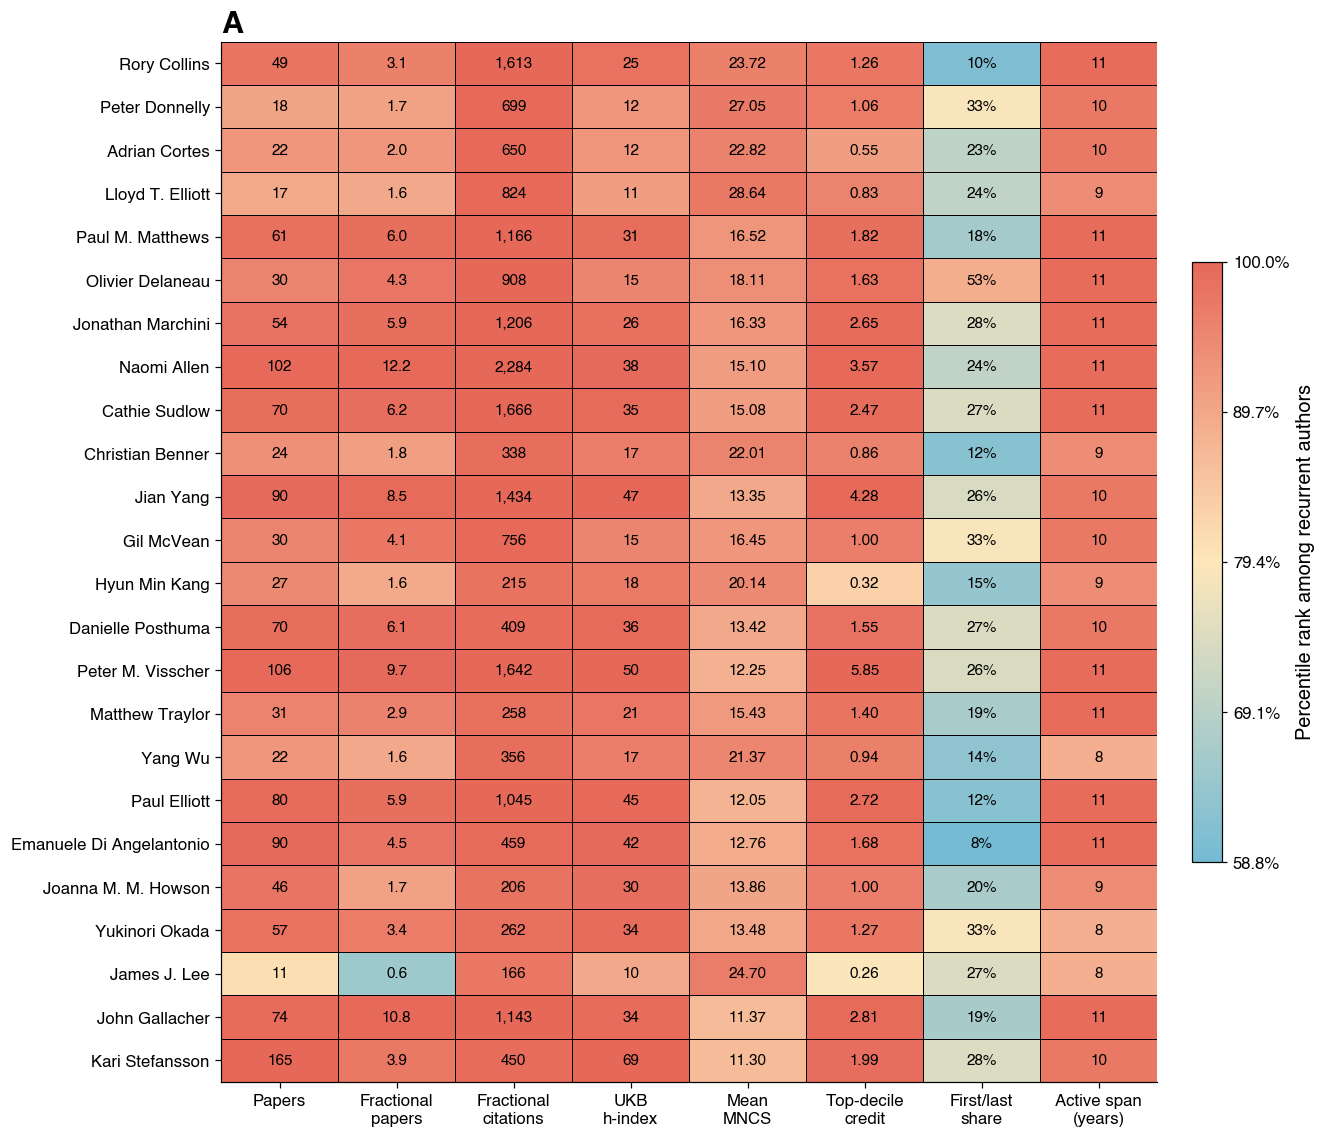

Saved: output/figures/data_analysis/03_academic_impact/fig_author_influence_fingerprint_heatmap.pdf
Saved: output/figures/data_analysis/03_academic_impact/fig_author_influence_fingerprint_heatmap.png


**Suggested caption:** Multidimensional profiles of the 24 highest-ranked authors by the composite UK Biobank influence score, 2015-2025. Numbers are observed values; colours indicate metric-specific percentile ranks among authors with at least three papers, using the observed minimum and maximum. Missing ranks are uncoloured. Top-decile credit uses publication-year and field-specific thresholds. Author identities retain the legacy name-based fallback used in the cohort analysis.

In [21]:
fig = Q.author_fingerprint(author_summary, IMPACT_SHORT)
Q.publish(fig, "fig_author_influence_fingerprint_heatmap", ARTIFACTS)


# Part III: Showcase+ citation and disciplinary figures

This notebook makes the disciplinary and citation figures from the publication-level full-endpoint parquet. It does not run BERTopic and does not depend on any topic-model cache.

The input is the repository's `showcase_plus_all_endpoints_wide.parquet`. The analysis uses its publication fields only, so every figure is calculated from the same one-row-per-paper table. Figures are shown in the notebook and saved under `output/figures/data_analysis/03_academic_impact/citation_diagnostics/` as PNG and PDF files; the tables behind them remain under `output/non_topic_figures/tables/` as CSV files. Set `UKB_FULL_ENDPOINT_PARQUET` or `UKB_NON_TOPIC_OUTPUT` to override the input or table-output root, respectively.

Topic waves and other BERTopic outputs are deliberately kept in the topic notebook. The earlier source-route comparison is also omitted because `source_route` is not a field in the full-endpoint parquet and would require a second input table. The former leading-publication-venues chart is now Figure 5H, built from the same Showcase+ fields by `05_author_characteristics.ipynb`; it is not duplicated here.


## 1. set the input




In [22]:
import os
PARQUET_PATH = Path(os.environ.get("UKB_FULL_ENDPOINT_PARQUET", P.SHOWCASE_PLUS)).expanduser()
# Preserve the existing table location for downstream readers, but put all figures
# under output/figures/data_analysis/03_academic_impact.
TABLE_DIR = Path(os.environ.get("UKB_NON_TOPIC_OUTPUT", P.OUTPUT / "non_topic_figures")).expanduser() / "tables"
CITATION_ARTIFACTS = P.ArtifactRegistry(TABLE_DIR)
if not PARQUET_PATH.exists():
    raise FileNotFoundError(f"Full-endpoint parquet not found: {P.raw_path(PARQUET_PATH)}")
print("Input:", P.raw_path(PARQUET_PATH))


Input: data/showcase/showcase_plus/showcase_plus_all_endpoints_wide.parquet


## 2. Analysis settings and shared style

Publications are included from 1 January 2013 through 31 December 2025. The August 2026 citation snapshot remains separate from that publication cutoff and is used to calculate citations per year.


In [23]:
import ast
import re
MIN_YEAR = ANALYSIS_START_YEAR
MAX_YEAR = ANALYSIS_END_YEAR
CITATION_SNAPSHOT_YEAR = 2026
TOP_N = 15


## 3. Load the publication table

Only the columns needed below are read from the wide parquet. Duplicate publication IDs are checked and collapsed before analysis, so one paper cannot be counted twice because of the endpoint merge.


In [24]:
PUBLICATION_COLUMNS = [
    "id",
    "title",
    "year",
    "date",
    "times_cited",
    "field_citation_ratio",
    "relative_citation_ratio",
    "category_for_2020",
]

papers = pd.read_parquet(PARQUET_PATH, columns=PUBLICATION_COLUMNS)

missing = [column for column in PUBLICATION_COLUMNS if column not in papers.columns]
if missing:
    raise ValueError(f"The parquet is missing required publication columns: {missing}")

input_rows = len(papers)
duplicate_ids = int(papers["id"].duplicated(keep=False).sum())
papers = papers.drop_duplicates(subset="id", keep="first").copy()

papers["year"] = pd.to_numeric(papers["year"], errors="coerce")
papers["times_cited"] = pd.to_numeric(papers["times_cited"], errors="coerce").fillna(0)
papers["field_citation_ratio"] = pd.to_numeric(
    papers["field_citation_ratio"], errors="coerce"
)
papers["relative_citation_ratio"] = pd.to_numeric(
    papers["relative_citation_ratio"], errors="coerce"
)

analysis_papers = filter_analysis_window(papers)
analysis_papers = analysis_papers[analysis_papers["year"].between(MIN_YEAR, MAX_YEAR)].copy()
analysis_papers["year"] = analysis_papers["year"].astype(int)
analysis_papers["citation_age_years"] = (
    CITATION_SNAPSHOT_YEAR - analysis_papers["year"] + 1
).clip(lower=1)
analysis_papers["citations_per_year"] = (
    analysis_papers["times_cited"] / analysis_papers["citation_age_years"]
)

if analysis_papers.empty:
    raise ValueError("No eligible publication rows remain after the year checks.")

print(f"Rows read: {input_rows:,}")
print(f"Duplicate-ID rows found: {duplicate_ids:,}")
print(f"Unique publications: {len(papers):,}")
print(
    f"Complete-year analysis set: {len(analysis_papers):,} "
    f"({analysis_papers['year'].min()}-{analysis_papers['year'].max()})"
)
display(analysis_papers.head(3))


Rows read: 26,109
Duplicate-ID rows found: 0
Unique publications: 26,109
Complete-year analysis set: 23,442 (2013-2025)


,id,title,year,date,times_cited,field_citation_ratio,relative_citation_ratio,category_for_2020,citation_age_years,citations_per_year
0,pub.1000169743,Ethnic-Specific Obesity Cutoffs for Diabetes R...,2014,2014-08-07,223,32.97,5.16,"[{""id"":""80003"",""name"":""32 Biomedical and Clini...",13,17.153846
1,pub.1000305094,Data science for mental health: a UK perspecti...,2016,2016-10-01,56,8.91,1.36,"[{""id"":""80003"",""name"":""32 Biomedical and Clini...",11,5.090909
2,pub.1001609820,"Ambient air pollution, traffic noise and adult...",2016,2016-10-20,73,22.92,2.67,"[{""id"":""80003"",""name"":""32 Biomedical and Clini...",11,6.636364


## 4. Prepare journal and Field of Research values

Dimensions stores journals and Fields of Research as JSON-like values. This cell turns them into ordinary labels. Four-digit FoR 2020 groups are used for the field plots. When a paper has several groups, its weight is split equally between them rather than counted several times.


In [25]:
def parse_json_like(value):
    if isinstance(value, (list, dict)):
        return value
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    text = str(value).strip()
    if not text or text.lower() in {"nan", "none", "null"}:
        return None
    try:
        return json.loads(text)
    except (json.JSONDecodeError, TypeError):
        try:
            return ast.literal_eval(text)
        except (ValueError, SyntaxError):
            return text


def four_digit_for_groups(value):
    parsed = parse_json_like(value)
    if isinstance(parsed, dict):
        parsed = [parsed]
    if not isinstance(parsed, list):
        return []

    groups = {}
    for item in parsed:
        if isinstance(item, dict):
            name = str(item.get("name") or item.get("title") or "").strip()
        else:
            name = str(item).strip()
        match = re.match(r"^(\d{4})\s+(.+)$", name)
        if match:
            groups[match.group(1)] = match.group(2).strip()
    return sorted(groups.items())


for_rows = []
for row in analysis_papers[
    ["id", "year", "times_cited", "category_for_2020"]
].itertuples(index=False):
    groups = four_digit_for_groups(row.category_for_2020)
    if not groups:
        continue
    weight = 1.0 / len(groups)
    for code_value, field_name in groups:
        for_rows.append({
            "id": row.id,
            "year": row.year,
            "times_cited": row.times_cited,
            "for_code": code_value,
            "for_name": field_name,
            "fractional_papers": weight,
            "fractional_citations": row.times_cited * weight,
        })

for_long = pd.DataFrame(for_rows)
if for_long.empty:
    raise ValueError("No four-digit FoR 2020 assignments could be parsed.")

print(f"Papers with a four-digit FoR group: {for_long['id'].nunique():,}")
print(f"Distinct four-digit FoR groups: {for_long['for_code'].nunique():,}")


Papers with a four-digit FoR group: 22,793
Distinct four-digit FoR groups: 113


## 5. Disciplinary composition and citation impact

This 2x2 figure combines the former sections 5, 6, 7 and 9. All four analyses retain their original CSV tables.

**A. Disciplinary composition.** Showcase+ papers are grouped by four-digit FoR 2020 assignments. Fractional counting keeps the total contribution of each paper at one even when Dimensions assigns it to several fields.

**B. Cumulative publication output and citation stock.** Publication growth and citation impact share the same percentage scale. Citation counts are those currently attached to each paper, grouped by publication year; this is not a historical record of how many citations existed in each calendar year.

**C. Citation impact by Field of Research.** The same fractional rule is used for citations: if a paper belongs to two four-digit FoR groups, each receives half of that paper's citation count. The bars show how citation impact is distributed without inflating the overall total.

**D. Field-normalised citation performance.** Field Citation Ratio is available for many, but not all, publications. A value of one is the Dimensions benchmark; values above one indicate citation performance above that benchmark. The curve shows the full distribution rather than reducing it to a single mean. If FCR is unavailable in a future export, the panel falls back to RCR and then to citations per year.


saved output/non_topic_figures/tables/fig01_disciplinary_composition.csv
saved output/non_topic_figures/tables/fig02_cumulative_output_and_citation_stock.csv
saved output/non_topic_figures/tables/fig04_field_citation_impact.csv
saved output/non_topic_figures/tables/fig07_normalised_citation_thresholds.csv


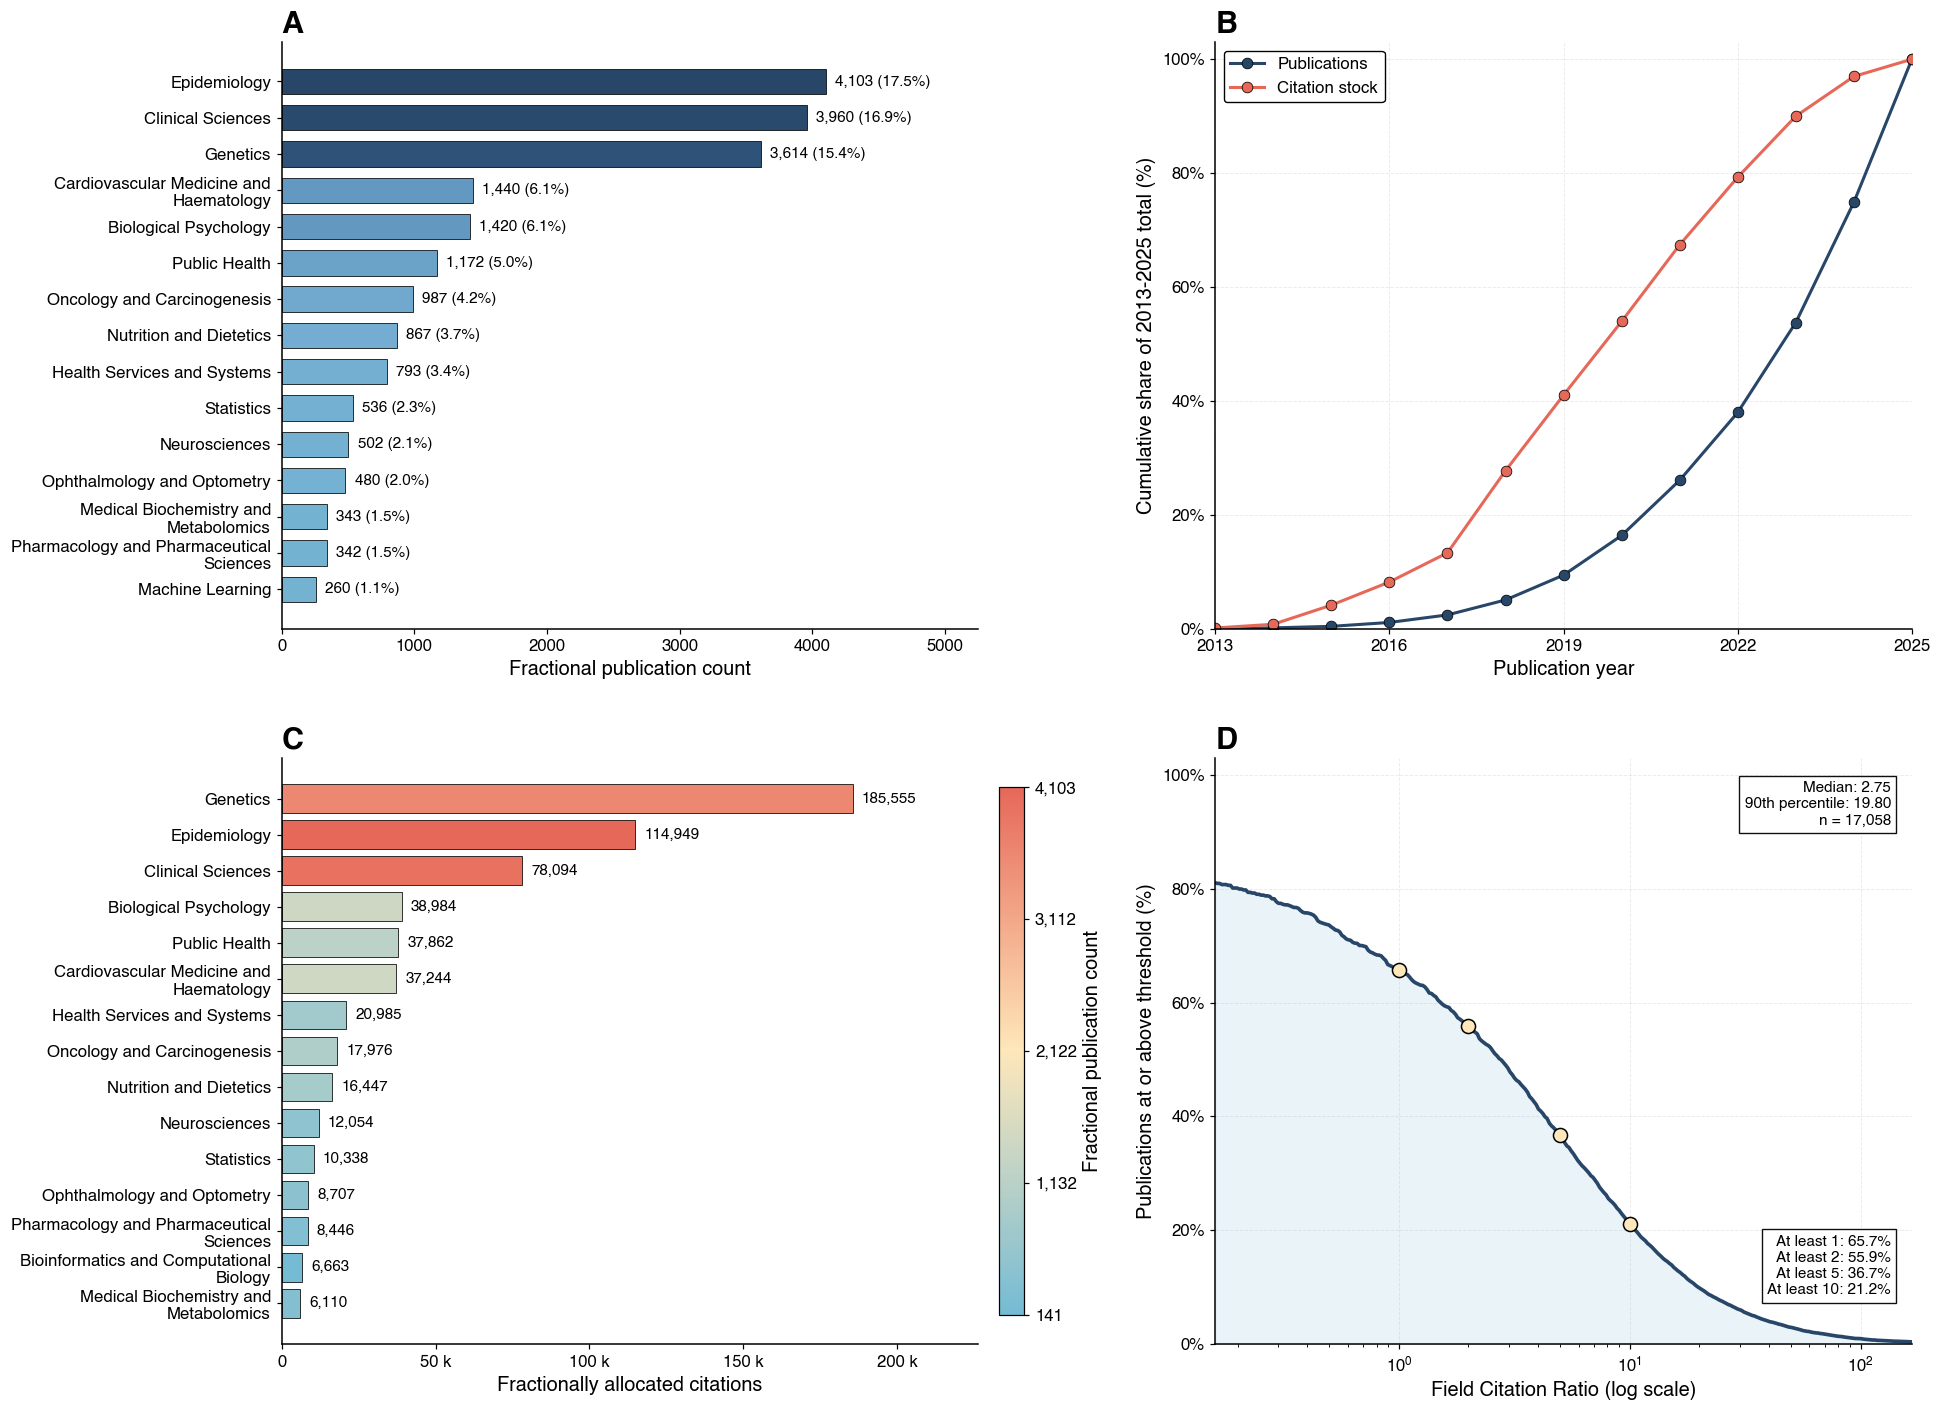

Saved: output/figures/data_analysis/03_academic_impact/citation_diagnostics/fig01_disciplinary_and_citation_overview.pdf
Saved: output/figures/data_analysis/03_academic_impact/citation_diagnostics/fig01_disciplinary_and_citation_overview.png


**Suggested caption:** (A) Pooled disciplinary composition of Showcase+ publications, 2013-2025. Each paper contributes equally across its assigned four-digit Fields of Research. Bars show the 15 largest fields; percentages use all included publications, including unclassified papers, as denominator. (B) Cumulative shares of Showcase+ publications and their citation stock by publication year, 2013-2025. Citations are those recorded at the data snapshot, assigned to the year of the cited paper; this is not a historical time series of citations received in each year. (C) The 15 Fields of Research with the largest allocated citation stock among Showcase+ papers published in 2013-2025. Both papers and their snapshot citations are divided equally across assigned four-digit fields. Bar length shows citations and colour shows fractional publication count, scaled to the observed range among the displayed fields. (D) Exceedance distribution of field citation ratio for Showcase+ papers, 2013-2025 (17,058 non-negative measured values). The curve spans the 0.5th to 99.5th percentiles of positive values; percentages include measured zeros in their denominator. Values above one exceed the metric's reference benchmark.

In [26]:
fig = Q.citation_overview(analysis_papers, for_long, TOP_N)
Q.publish(fig, "fig01_disciplinary_and_citation_overview", CITATION_ARTIFACTS,
          subdirectory="citation_diagnostics")


## 6. Citation concentration

Panel A orders papers from most to least cited. It answers a straightforward question: what share of all citations is carried by the top 1%, 5%, 10%, and so on? The diagonal is the equal-share reference.

Panel B shows age-adjusted citation impact by publication cohort. Older papers have had more time to collect citations. To make broad cohorts easier to compare, each paper's current citation count is divided by the number of years since publication. The distributions are still descriptive: this adjustment handles exposure time, not differences between research fields. Both analyses retain their original CSV tables.


saved output/non_topic_figures/tables/fig05_citation_concentration_curve.csv
saved output/non_topic_figures/tables/fig05_citation_concentration_checkpoints.csv
saved output/non_topic_figures/tables/fig06_age_adjusted_citation_cohorts.csv


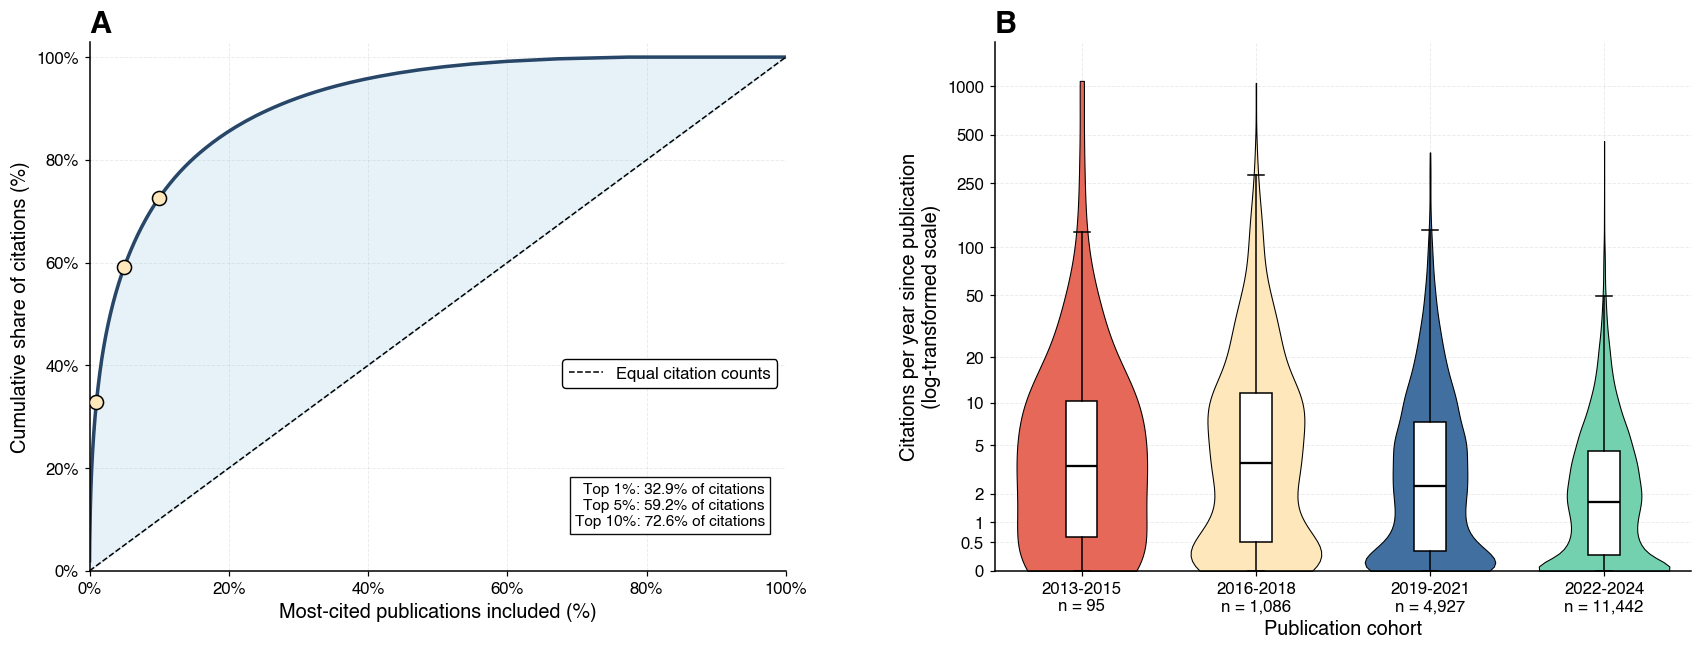

Saved: output/figures/data_analysis/03_academic_impact/citation_diagnostics/fig05_citation_concentration.pdf
Saved: output/figures/data_analysis/03_academic_impact/citation_diagnostics/fig05_citation_concentration.png


**Suggested caption:** (A) Concentration of snapshot citations across Showcase+ papers published in 2013-2025, ranked from most to least cited. Highlighted points mark the leading 1%, 5% and 10% of publications. The dashed diagonal represents equal citation counts across papers. (B) Citation-rate distributions by publication cohort through 2024. Snapshot citations are divided by 2026 minus publication year plus one. Violins show log10(1 + annualised citations); boxes show the median and interquartile range, with whiskers extending to 1.5 interquartile ranges. Tick labels are on the original citation-rate scale. Annualisation is not field normalisation and does not remove all citation-age differences.

In [27]:
fig = Q.citation_concentration_and_cohorts(analysis_papers, CITATION_SNAPSHOT_YEAR, MIN_YEAR)
Q.publish(fig, "fig05_citation_concentration", CITATION_ARTIFACTS,
          subdirectory="citation_diagnostics")


# Part IV: Assembled publication panels

The main figure and three supplementary figures reuse the field aggregates from Part I;
they do not rerun the data build. All distinct diagnostics remain above. The author
portfolio and journal-impact panels belong to the author-characteristics notebook and
are not repeated here.

| Figure | Contents |
|---|---|
| Figure 5 | A: activity versus citation impact; B: activity ranking; C: top-decile share; D-K: field-specific quality footprints |
| Supplementary figure 1 | Impact map for 25 fields |
| Supplementary figure 2 | Top-decile citation-pool shares for those 25 fields |
| Supplementary figure 3 | Growth rates and corresponding publication trajectories |


## 1. Publication-figure style


In [28]:
STYLE = load_style("03_academic_impact_panels")
TABLE_DIR = ARTIFACTS.table_dir
print("Figures:", P.raw_path(STYLE["savedir"]))


Figures: output/figures/data_analysis/03_academic_impact


## 2. Reuse the validated field analysis

The assembly adds the retained author tables and growth summaries to the existing context.


In [29]:
D = NP.build_panel_data(context=CTX)
NP.assert_parameters_match(D)


loading both arms from data/analysis/academic_impact/for_counts_api (API pathway) …
  author arm: 266,131 author-paper rows, 88,662 distinct authors
  growth: 23 field(s) clear the floors; UK Biobank overall 26%/yr over 2021-2025

UK Biobank is 0.044% of the whole database over 2015-2025 (n_papers).
done.


## 3. Main figure: academic impact

The citation-pool share in C and the solid bands in D-K have the same UK Biobank
top-decile numerator but different denominators: C uses the field's top-decile pool,
whereas D-K use all publications in the field. In-band percentages describe the
fraction of UK Biobank's own field output. The citation thresholds are tabulated below.


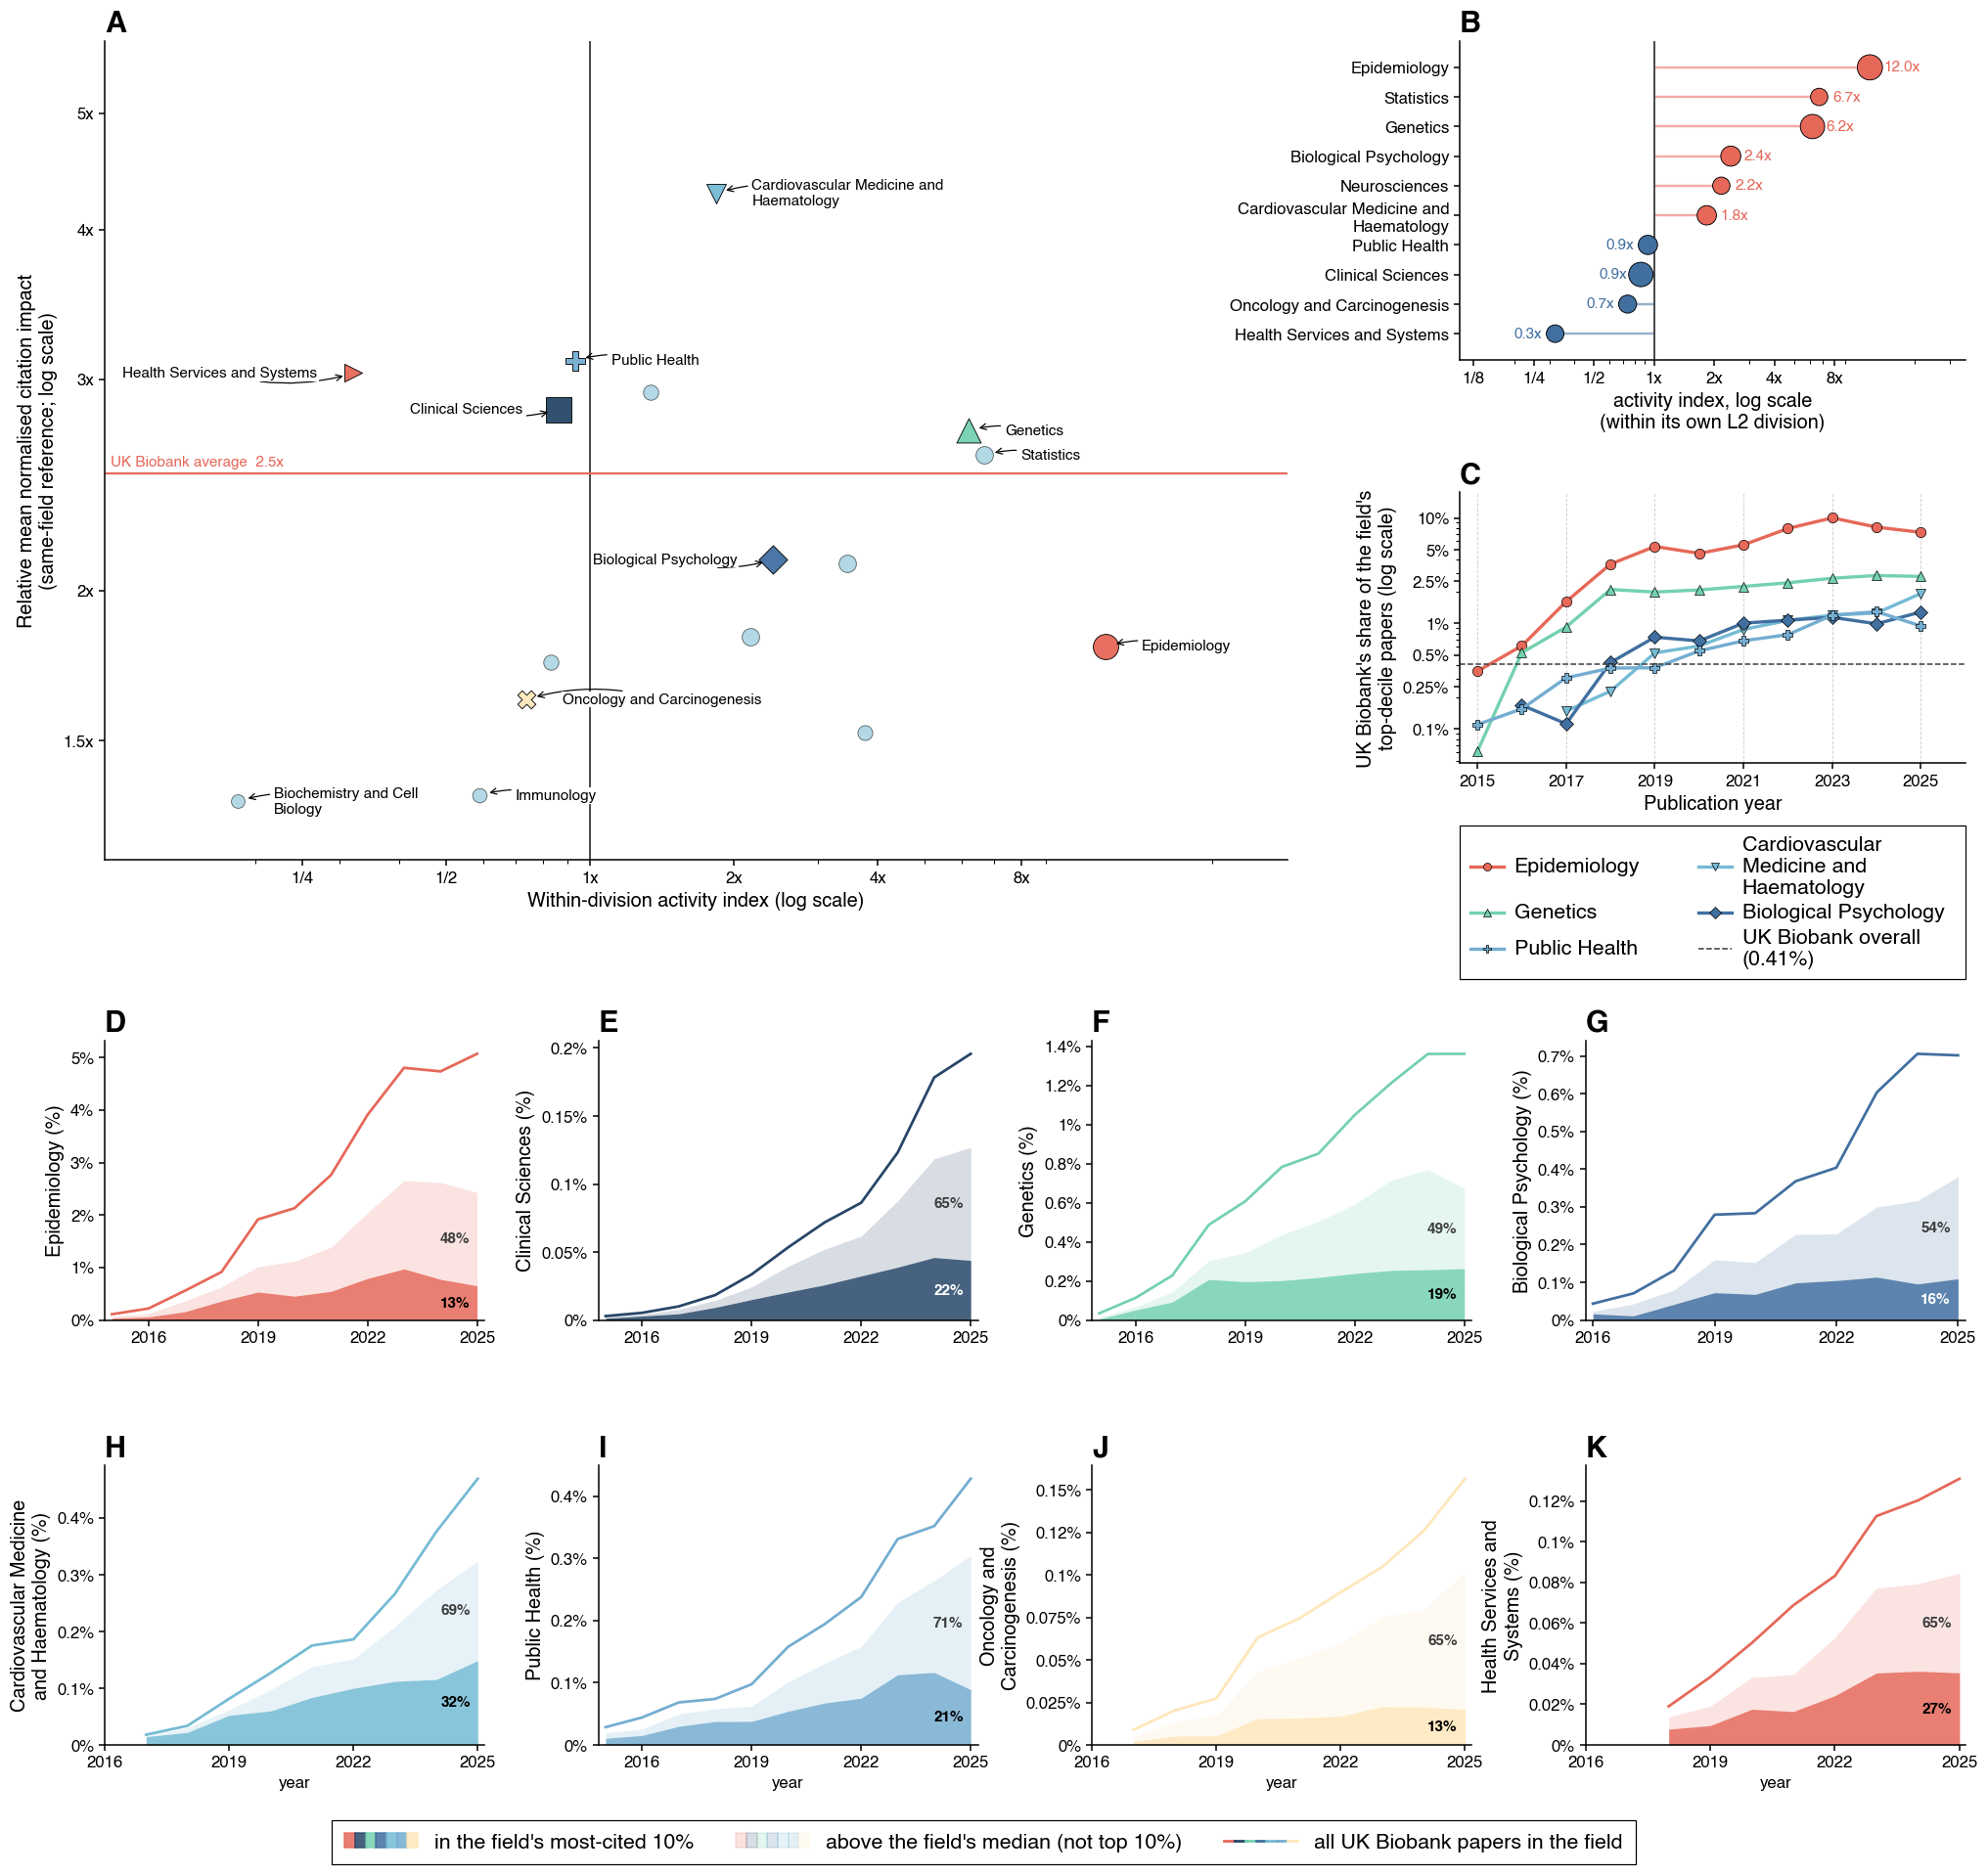

Saved: output/figures/data_analysis/03_academic_impact/03_01_figure_05_academic_impact.pdf
Saved: output/figures/data_analysis/03_academic_impact/03_01_figure_05_academic_impact.png


**Suggested caption:** Academic position of UK Biobank research, 2015-2025. (A) Within-division activity index versus relative mean normalised citation impact for the 16 largest eligible fields; marker area reflects publication count. The red horizontal line marks overall UK Biobank impact and the vertical line marks activity parity. (B) Activity indices for the ten largest fields. (C) Annual UK Biobank shares of field-specific top-decile citation pools for the five leading fields by final-year share; the dashed line is the pooled UK Biobank share. (D-K) UK Biobank publications as a percentage of all publications in each of eight fields, partitioned into top-decile (solid) and other above-median (pale) citation credit. In-band percentages describe the corresponding fractions of UK Biobank's own field output. Citation thresholds are measured separately by field and publication year; integer ties can produce achieved fractions different from 10% and 50%.

In [30]:
fig_main = NP.figure_main(D, save=False)
Q.publish(fig_main, P.MAIN_FIGURE_STEMS[5], ARTIFACTS)


### 4.1 What panel D's bars were worth, in citations *(for the methods section)*

Panel D cuts each field's footprint at that field's own top decile and median. Both
cut-offs are **measured** per (year, field) by binary search against the live index, not
interpolated — and both fall steeply with publication year because citations accrue:
2015's tenth-best Epidemiology paper needed 63 citations, 2025's needs 8. That is the
clock, not a decline in standards, and it is exactly why the cut is taken per year.

**Read `median_achieved_pct` before quoting a median band.** Citations are small integers
with enormous ties, so in a recent year the cut lands at "≥ 1 citation" and keeps as
little as 34% of the field. The count above the cut is still exact; what is approximate is
calling it the 50th percentile.

The table holds the cells **panel D draws** — the eight fields, inside the window, where
the decile was actually measured. That is a subset of the **213** measured L4 cells across
all 113 fields, over which the decile lands at 7.30–10.00% (median 9.77%) and the median
at 34.23–50.00% (median 47.69%).

In [31]:
cuts = NP.cut_off_table(D)
ARTIFACTS.save_table(cuts, "panel_d_citation_cutoffs.csv")
print(f"{len(cuts)} measured (year, field) cells -> "
      f"{P.raw_path(TABLE_DIR / 'panel_d_citation_cutoffs.csv')}\n")

_m = cuts.dropna(subset=["median_achieved_pct"])
print(f"top-decile cut achieved  {cuts.top_decile_cites.notna().sum()} cells")
print(f"median cut achieved      {_m.median_achieved_pct.min():.2f}% - "
      f"{_m.median_achieved_pct.max():.2f}%  (median {_m.median_achieved_pct.median():.2f}%); "
      f"{int((_m.median_achieved_pct < 45).sum())} cells more than five points short\n")

# The final year for each field, which is what the panels' sharp end shows.
display(cuts[cuts.year == NP.ANALYSIS_MAX]
        .set_index("field")[["top_decile_cites", "median_cites", "mean_cites",
                             "median_achieved_pct"]])


saved output/tables/03_academic_impact/panel_d_citation_cutoffs.csv
81 measured (year, field) cells -> output/tables/03_academic_impact/panel_d_citation_cutoffs.csv

top-decile cut achieved  81 cells
median cut achieved      34.77% - 50.00%  (median 48.13%); 12 cells more than five points short



,top_decile_cites,median_cites,mean_cites,median_achieved_pct
field,,,,
Biological Psychology,7.0,1.0,2.21,49.03
Cardiovascular Medicine and Haematology,5.0,1.0,1.45,34.77
Clinical Sciences,5.0,1.0,1.69,41.76
Epidemiology,8.0,2.0,2.90,39.06
Genetics,7.0,2.0,2.60,38.00
Health Services and Systems,5.0,1.0,1.72,42.34
Oncology and Carcinogenesis,8.0,1.0,2.67,48.24
Public Health,6.0,1.0,2.09,48.44


## 5. Supplementary figure 1: expanded impact map

The map includes the 25 largest eligible fields. Full field names are connected to their
markers by curved arrows; the principal eight fields retain their colours across figures.


saved output/tables/03_academic_impact/si1_impact_table_all_weights.csv


,ukbb_papers,activity_x,rci_top10f,act_top10f,rci_top50f,act_top50f,rci_mncs,act_mncs
field,,,,,,,,
Epidemiology,6256.0,12.003,1.965,12.902,1.134,14.367,1.797,44.029
Clinical Sciences,5458.0,0.859,3.118,0.617,1.477,0.563,2.832,2.090
Genetics,5321.0,6.201,2.484,4.774,1.196,4.433,2.719,19.496
Biological Psychology,2244.0,2.420,2.064,1.926,1.104,1.986,2.123,6.854
Cardiovascular Medicine and Haematology,1904.0,1.835,4.302,2.135,1.677,1.605,4.289,6.758
Public Health,1864.0,0.932,3.231,1.647,1.453,1.428,3.111,5.918
Oncology and Carcinogenesis,1359.0,0.738,1.946,0.382,1.370,0.518,1.624,1.029
Health Services and Systems,1207.0,0.320,3.080,0.604,1.392,0.526,3.037,1.985
Statistics,1136.0,6.695,2.088,2.229,1.230,2.532,2.594,8.838


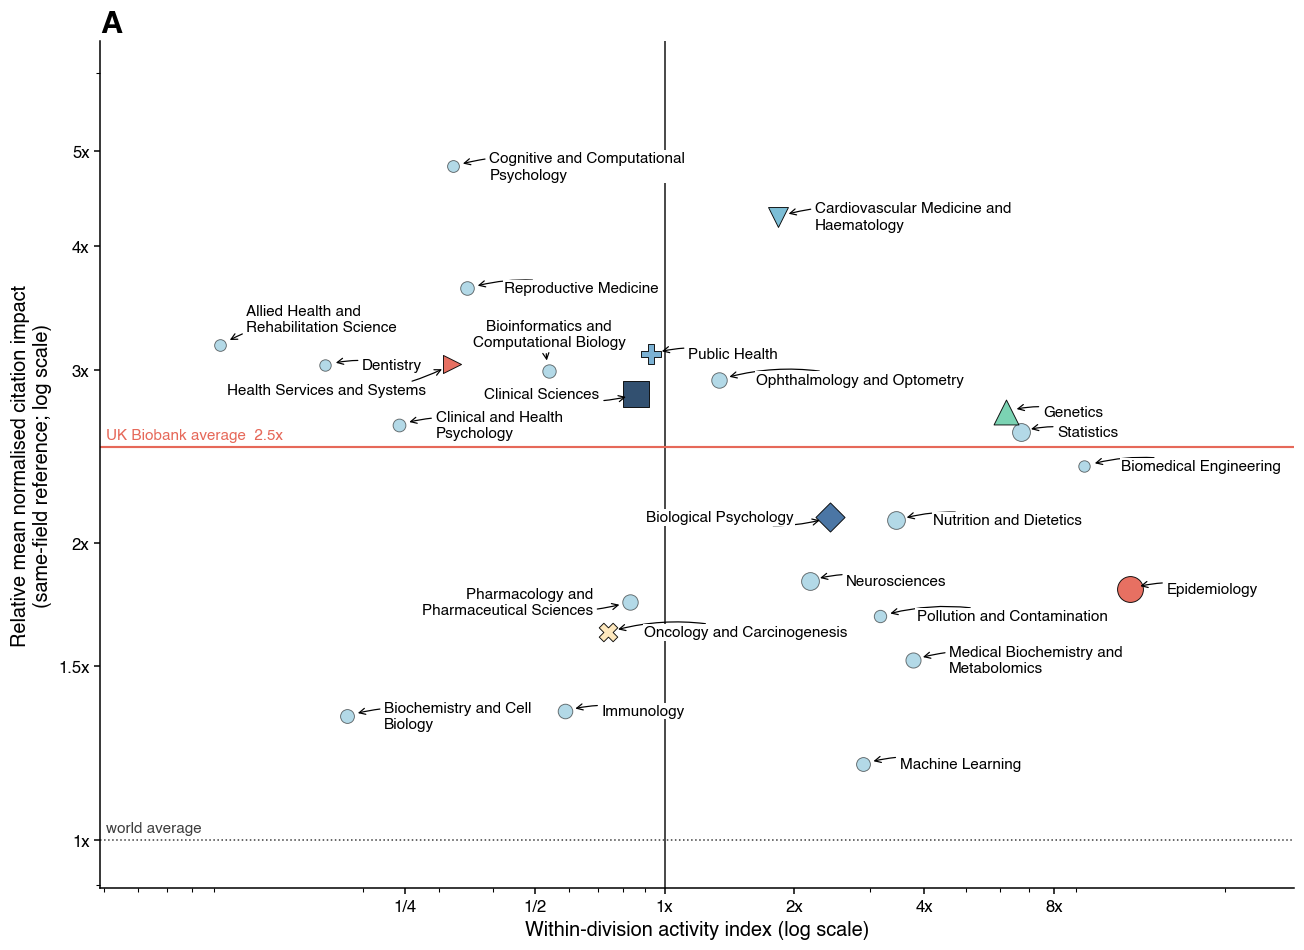

Saved: output/figures/data_analysis/03_academic_impact/03_02_supplementary_figure_01_impact_map_full.pdf
Saved: output/figures/data_analysis/03_academic_impact/03_02_supplementary_figure_01_impact_map_full.png


**Suggested caption:** Research specialisation and citation impact of UK Biobank publications, 2015-2025, across the 25 largest fields with both measures available. The horizontal axis compares the field's share of UK Biobank output with its reference-literature share within the same research division. The vertical axis compares mean normalised citation impact with the same-field reference. Both axes are logarithmic; marker area represents publication count. The red line marks overall UK Biobank impact, and parity lines mark a ratio of one. Curved arrows identify every field without covering its marker.

In [32]:
# Preserve the full multi-measure impact table alongside the expanded map.
_cols = ["ukbb_papers", "activity_x"] + [c for c in D["IMPACT"].columns
                                      if c.startswith(("rci_", "act_"))]
impact_out = (D["IMPACT"][_cols]
              .assign(field=[D["label_of"](c) for c in D["IMPACT"].index])
              .set_index("field").nlargest(NP.MAP_M_SI, "ukbb_papers").round(3))
ARTIFACTS.save_table(impact_out, "si1_impact_table_all_weights.csv", index=True)
display(impact_out)
fig_si1 = NP.figure_si_impact_map(D, save=False)
Q.publish(fig_si1, "03_02_supplementary_figure_01_impact_map_full", ARTIFACTS)


## 6. Supplementary figure 2: top-decile citation-pool shares

The same 25 fields as the expanded impact map are shown on common logarithmic axes.
Separate panels replace the overlaid lines and crowded labels; no field has been dropped.
Every measured year is retained. Gaps remain gaps, and zeros cannot be plotted on a log scale.


saved output/tables/03_academic_impact/top_decile_share_endpoints.csv
saved output/tables/03_academic_impact/top_decile_share_by_field_year.csv


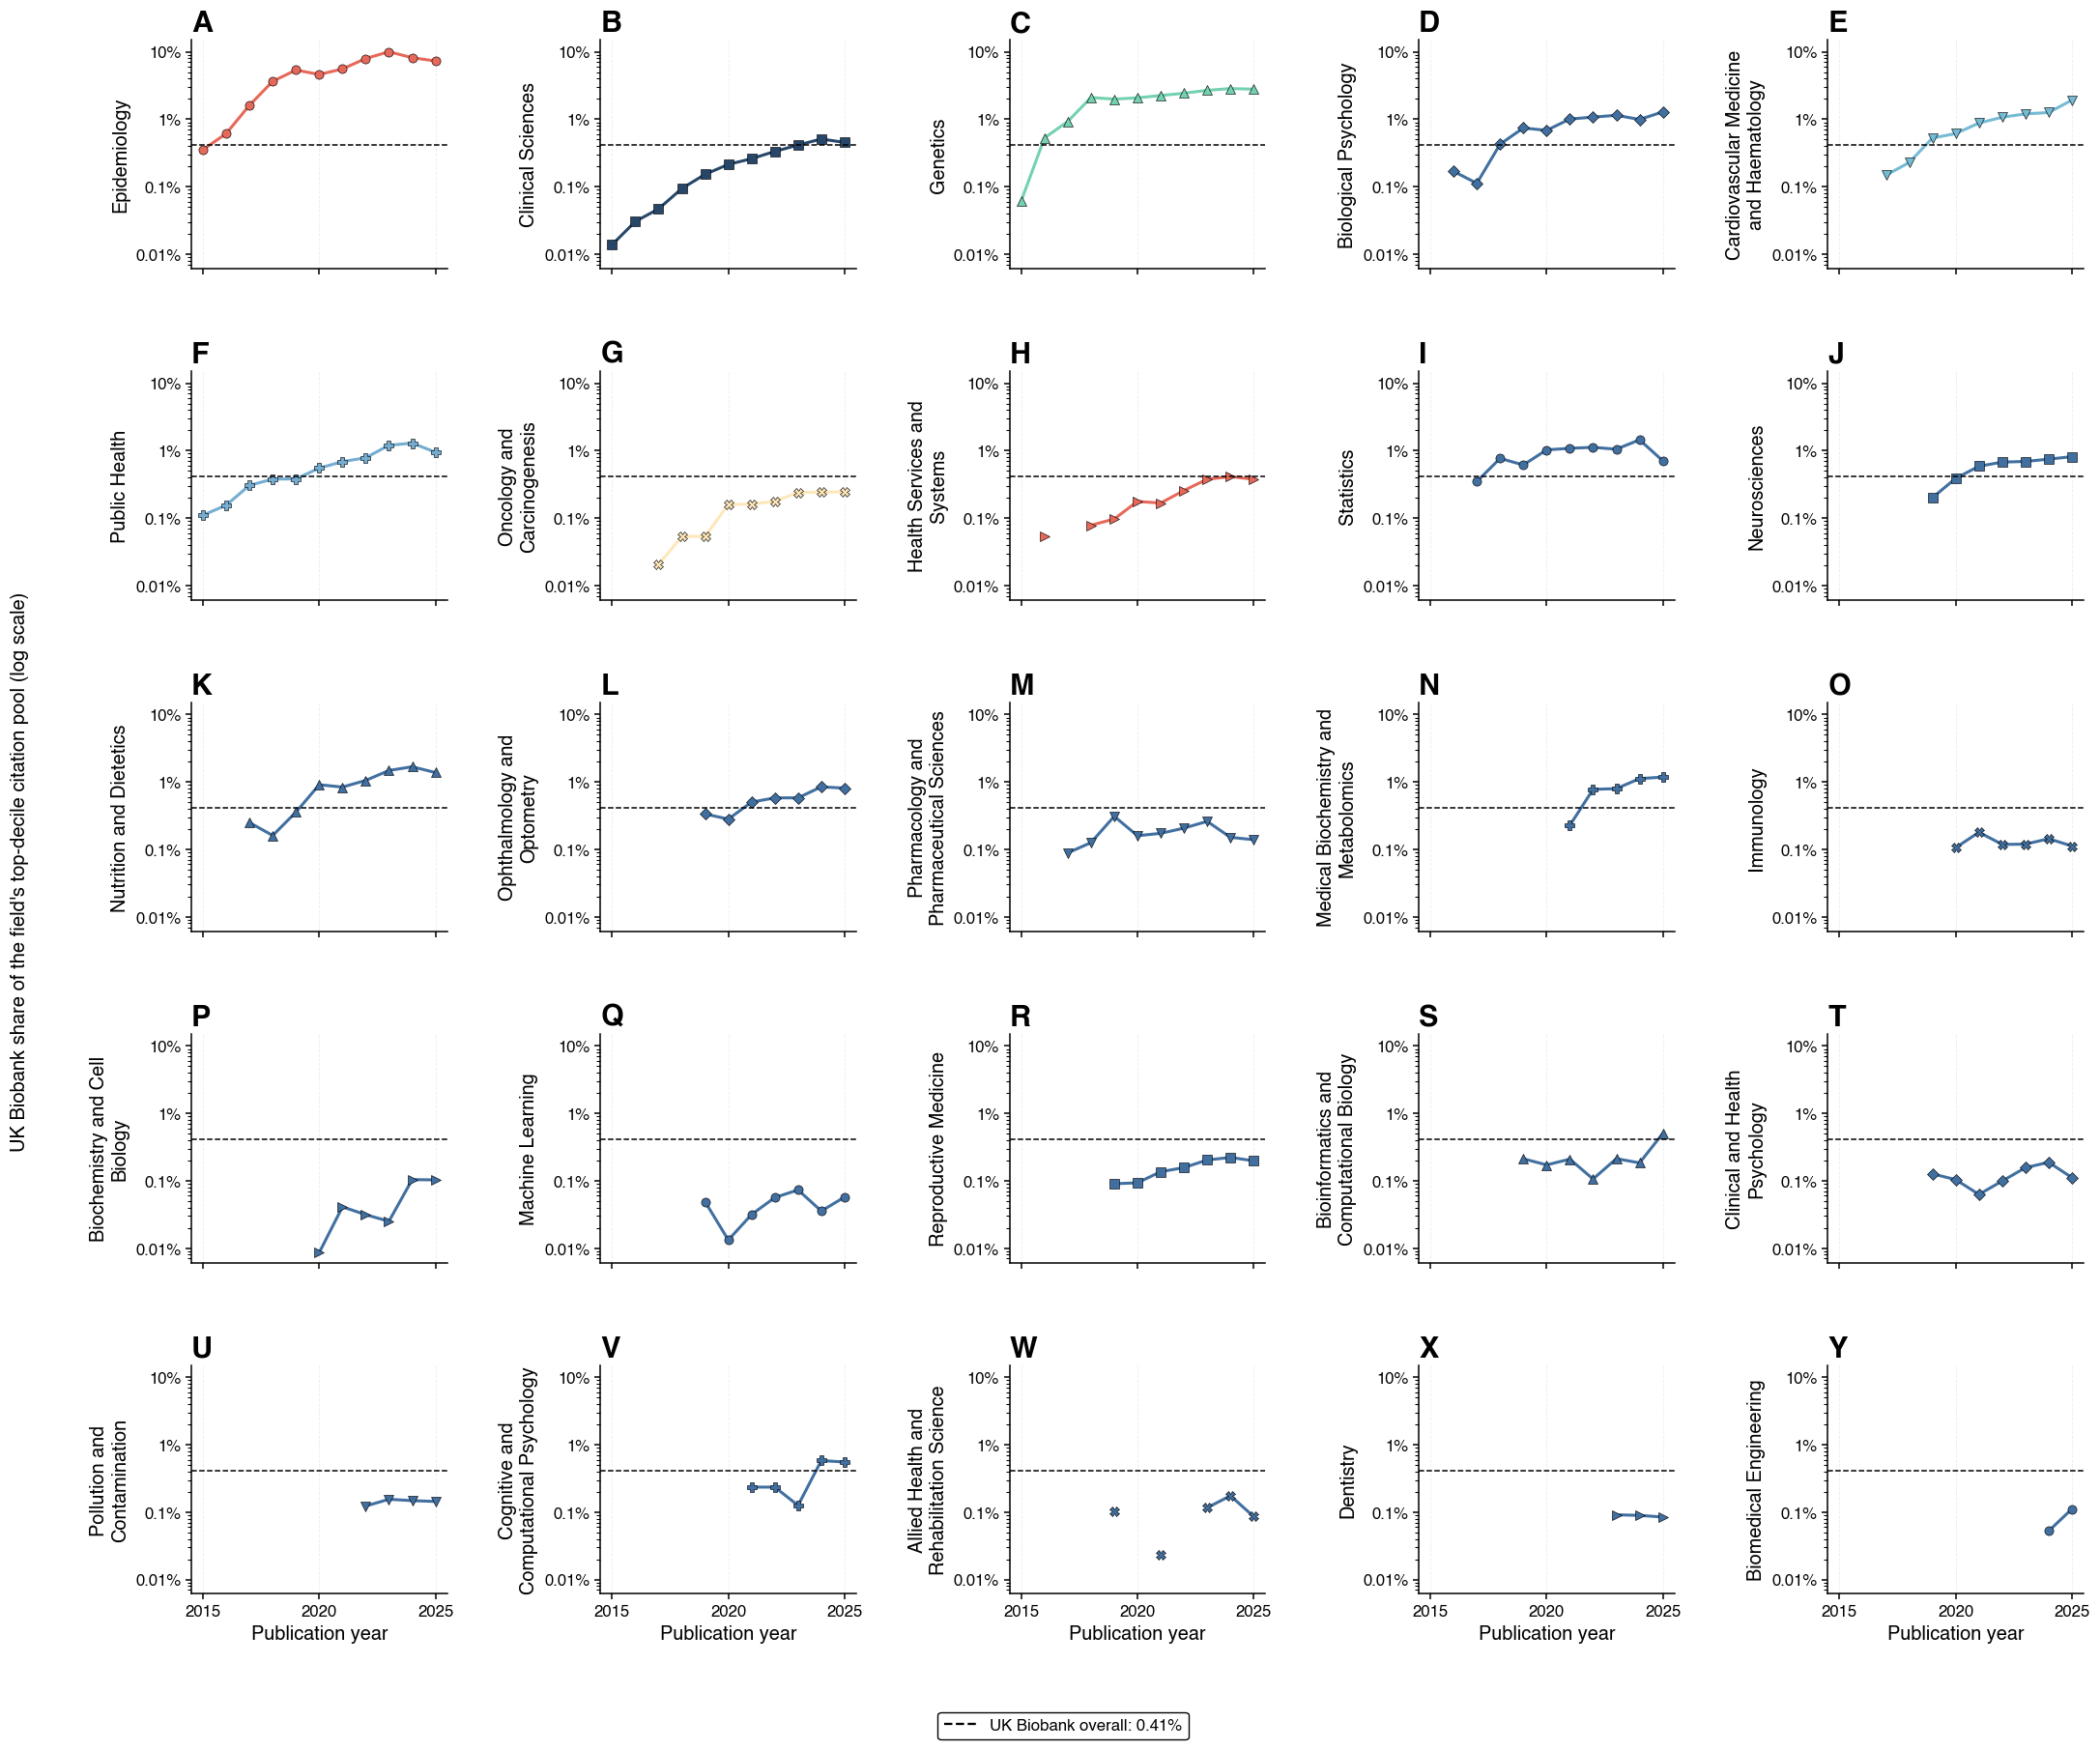

Saved: output/figures/data_analysis/03_academic_impact/03_03_supplementary_figure_02_top_decile_share.pdf
Saved: output/figures/data_analysis/03_academic_impact/03_03_supplementary_figure_02_top_decile_share.png


**Suggested caption:** UK Biobank's share of the measured top-decile citation pool in its 25 largest fields with available activity and citation-impact estimates (A-Y). All panels use the same logarithmic percentage scale. Each numerator is the field-year top-decile credit assigned to UK Biobank papers; its denominator is the corresponding whole-database pool. Dashed lines mark the pooled UK Biobank share across all fields in 2015-2025. Missing measurements and zeros are not drawn on the logarithmic axes. These are the same fields as Supplementary Figure 1.

In [33]:
fig_si2 = NP.figure_si_top_decile(D, save=False)
Q.publish(fig_si2, "03_03_supplementary_figure_02_top_decile_share", ARTIFACTS)


## 7. Supplementary figure 3: growth rates and trajectories

The fastest-growing eligible fields are ranked by 2021-2025 compound annual growth.
The table retains reference growth, acceleration relative to 2017-2021 and activity indices.
The neighbouring trajectory panel shows the underlying counts on a logarithmic scale.


saved output/tables/03_academic_impact/si2_fastest_growing_fields.csv


,ukbb@2025,ukbb_%/yr,ukbb_accel_pp,world_%/yr,activity_x
label,,,,,
Medical Biochemistry and Metabolomics,200.0,73.6,-8.5,12.6,3.8
Biomedical Engineering,35.0,62.7,13.1,7.4,9.4
Biochemistry and Cell Biology,112.0,57.9,NaN,2.2,0.2
Clinical and Health Psychology,49.0,42.2,23.2,6.2,0.2
Neurosciences,329.0,39.9,-54.7,2.2,2.2
Cognitive and Computational Psychology,39.0,37.2,-15.9,5.1,0.3
Ophthalmology and Optometry,159.0,37.1,-46.0,2.4,1.3
Nutrition and Dietetics,308.0,34.9,-18.0,6.0,3.4
Bioinformatics and Computational Biology,66.0,34.8,-43.0,0.9,0.5


saved output/tables/03_academic_impact/growth_rates_complete.csv


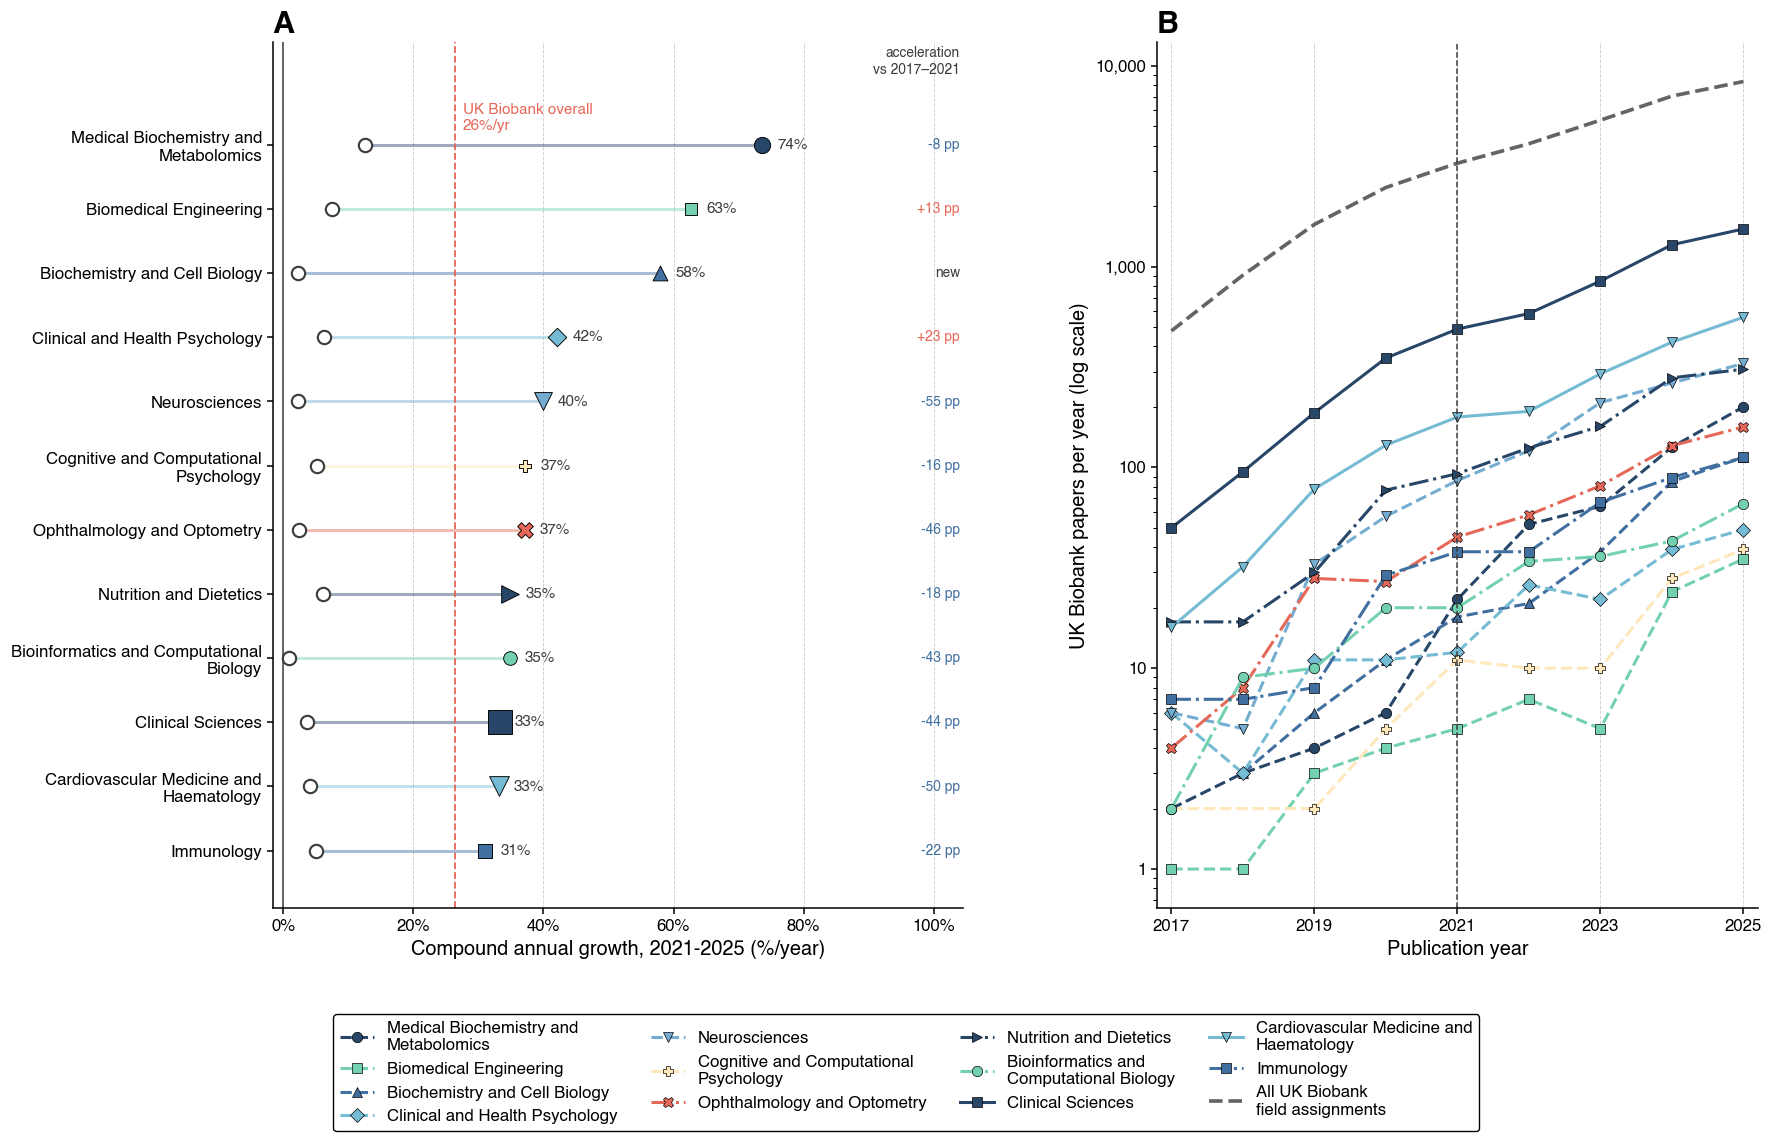

Saved: output/figures/data_analysis/03_academic_impact/03_04_supplementary_figure_03_growth.pdf
Saved: output/figures/data_analysis/03_academic_impact/03_04_supplementary_figure_03_growth.png


**Suggested caption:** Growth of UK Biobank research by field. (A) Compound annual growth during 2021-2025 for UK Biobank (filled markers) and the reference literature (hollow markers). Fields are ranked by UK Biobank growth, requiring at least five papers in 2021 and 20 in 2025. Filled-marker area reflects 2025 output. The right-hand column gives the change in annual growth relative to 2017-2021, in percentage points; 'new' denotes an unavailable earlier rate. (B) Publication trajectories for the same fields, on a logarithmic axis. The vertical dashed line marks 2021. The dashed curve sums UK Biobank publication-field assignments, so papers in multiple fields contribute more than once; the overall growth reference in A uses the same aggregate.

In [34]:
growth_out = (D["GROWTH"].head(NP.GROW_TOP_M)
              .set_index("label")[["ukbb_papers", "ukbb_now", "accel",
                                  "world_now", "activity_x"]]
              .rename(columns={"ukbb_papers": f"ukbb@{NP.GROW_NOW[1]}",
                               "ukbb_now": "ukbb_%/yr", "accel": "ukbb_accel_pp",
                               "world_now": "world_%/yr"}).round(1))
ARTIFACTS.save_table(growth_out, "si2_fastest_growing_fields.csv", index=True)
display(growth_out)
fig_si3 = NP.figure_si_growth(D, save=False)
Q.publish(fig_si3, "03_04_supplementary_figure_03_growth", ARTIFACTS)


## 8. Artifacts from this run

The manifest records the figures and diagnostic tables produced by this execution, rather than inventorying older files in the output directory.


In [35]:
ARTIFACTS.record_figures(CITATION_ARTIFACTS.figure_paths)
for path in CITATION_ARTIFACTS.table_paths:
    ARTIFACTS._register(ARTIFACTS.table_paths, path)
manifest = ARTIFACTS.save_manifest("panel_manifest.csv")
print(f"{len(ARTIFACTS.figure_paths)} figure files generated in this run.")
display(manifest)


saved output/tables/03_academic_impact/panel_manifest.csv
30 figure files generated in this run.


(             kind                                               name format                                               path  size_bytes  \
 0          figure                          01_whole_db_trends_for_L4    pdf  output/figures/data_analysis/03_academic_impac...       23360   
 1          figure                          01_whole_db_trends_for_L4    png  output/figures/data_analysis/03_academic_impac...      982231   
 2          figure               02_ukbb_contribution_for_L4_n_papers    pdf  output/figures/data_analysis/03_academic_impac...       26174   
 3          figure               02_ukbb_contribution_for_L4_n_papers    png  output/figures/data_analysis/03_academic_impac...     1020448   
 18         figure                    03_01_figure_05_academic_impact    pdf  output/figures/data_analysis/03_academic_impac...       40276   
 19         figure                    03_01_figure_05_academic_impact    png  output/figures/data_analysis/03_academic_impac...     2945746   